<a href="https://colab.research.google.com/github/aishamuqadus993-commits/Brain_Tumor_app/blob/main/Friday.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Step 1: check your Drive root
drive_root = "/content/drive/MyDrive"
print("Folders in MyDrive:")
for folder in sorted(os.listdir(drive_root)):
    print(f"  '{folder}'")

Folders in MyDrive:
  'Colab Notebooks'
  'Copy of Script (1).docx'
  'Gatekeeper'
  'MRI Imgs'
  'best_brain_tumor_model.h5'
  'training_log.csv'


In [ ]:
# -------- Import Libraries --------

import os                        # File and directory operations
import numpy as np               # Numerical operations
import random                    # For augmentation randomness
import pickle                    # Save/load MRI brain prototype for OOD rejection  ← ADDED
import warnings                  # Suppress noisy TF/sklearn logs                   ← ADDED
warnings.filterwarnings('ignore')

from PIL import Image, ImageEnhance          # Image processing

# TensorFlow / Keras core
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import backend as K    # Keep ONLY if your Grad-CAM uses K.function style

# Evaluation and calibration
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, accuracy_score
)
from sklearn.utils import shuffle
from sklearn.covariance import EmpiricalCovariance   # ← ADDED: robust covariance for Mahalanobis

# OOD (Out-of-Distribution) rejection — feature distance
from scipy.spatial.distance import mahalanobis       # ← ADDED: MRI prototype distance check

# Realtime / concurrency / IO
import cv2
import threading
from queue import Queue, Empty
import time

In [ ]:
import os
import shutil
import random

# -------- CONFIG --------
DATASET_DIR  = "/content/drive/MyDrive/MRI Imgs"
OUTPUT_DIR   = "/content/drive/MyDrive/MRI_Imagess_split"
SPLIT_RATIOS = (0.7, 0.15, 0.15)
RANDOM_SEED  = 42

# -------- Make output dirs --------
splits = ["train", "val", "test"]

# FIX 1: filter out hidden/system folders explicitly
class_names = [
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
    and not d.startswith('.')          # removes .ipynb_checkpoints etc
    and not d.startswith('__')         # removes __MACOSX etc
]

# FIX 2: early exit if no classes found
if not class_names:
    raise ValueError(f"No class folders found in {DATASET_DIR}. Check your path.")

print(f"Classes found: {class_names}\n")

for split in splits:
    for cls in class_names:
        os.makedirs(os.path.join(OUTPUT_DIR, split, cls), exist_ok=True)

# -------- Split each class --------
random.seed(RANDOM_SEED)

total_train = total_val = total_test = 0   # for final summary

for cls in class_names:
    cls_dir = os.path.join(DATASET_DIR, cls)
    images = [
        f for f in os.listdir(cls_dir)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    # FIX 3: skip empty class folders with a warning instead of silently failing
    if len(images) == 0:
        print(f"WARNING: No images found in class '{cls}', skipping.")
        continue

    random.shuffle(images)
    n_total = len(images)
    n_train = int(SPLIT_RATIOS[0] * n_total)
    n_val   = int(SPLIT_RATIOS[1] * n_total)
    n_test  = n_total - n_train - n_val     # remainder to test, no images lost

    train_imgs = images[:n_train]
    val_imgs   = images[n_train:n_train + n_val]
    test_imgs  = images[n_train + n_val:]

    for fname in train_imgs:
        shutil.copy(os.path.join(cls_dir, fname), os.path.join(OUTPUT_DIR, "train", cls, fname))
    for fname in val_imgs:
        shutil.copy(os.path.join(cls_dir, fname), os.path.join(OUTPUT_DIR, "val",   cls, fname))
    for fname in test_imgs:
        shutil.copy(os.path.join(cls_dir, fname), os.path.join(OUTPUT_DIR, "test",  cls, fname))

    total_train += len(train_imgs)
    total_val   += len(val_imgs)
    total_test  += len(test_imgs)

    print(f"  {cls:20s} → total={n_total:4d} | train={len(train_imgs):4d} | val={len(val_imgs):4d} | test={len(test_imgs):4d}")

# -------- Final summary --------
print(f"\n{'─'*55}")
print(f"  TOTAL               → train={total_train} | val={total_val} | test={total_test}")
print(f"  Grand total images  → {total_train + total_val + total_test}")
print(f"\n✅ Dataset split complete. Saved to: {OUTPUT_DIR}")

Classes found: ['glioma', 'no_tumor', 'meningioma', 'pituitary']

  glioma               → total=3754 | train=2627 | val= 563 | test= 564
  no_tumor             → total=1757 | train=1229 | val= 263 | test= 265
  meningioma           → total=2343 | train=1640 | val= 351 | test= 352
  pituitary            → total=2706 | train=1894 | val= 405 | test= 407

───────────────────────────────────────────────────────
  TOTAL               → train=7390 | val=1582 | test=1588
  Grand total images  → 10560

✅ Dataset split complete. Saved to: /content/drive/MyDrive/MRI_Imagess_split


  glioma               → 3754 images found
  meningioma           → 2343 images found
  no_tumor             → 1757 images found
  pituitary            → 2706 images found


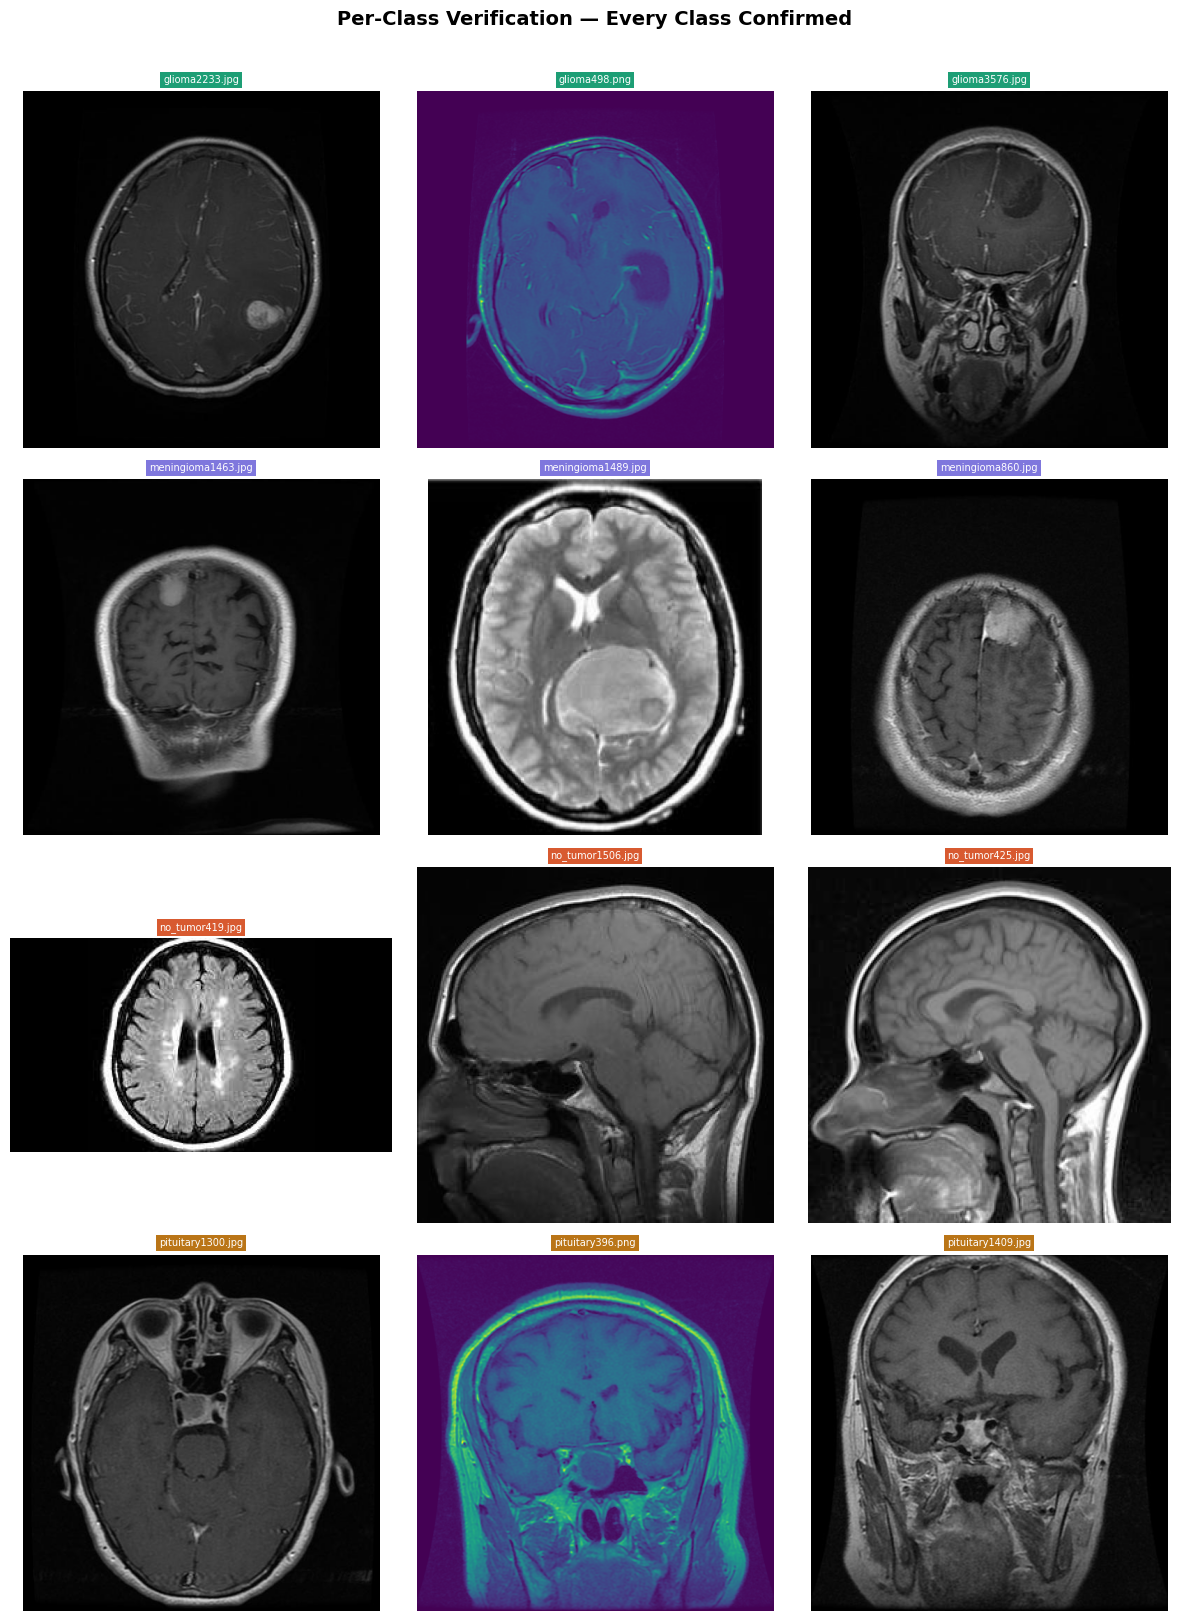


✅ Per-class verification complete.


In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

DATASET_DIR = "/content/drive/MyDrive/MRI Imgs"
SAMPLES_PER_CLASS = 3
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

class_names = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
    and not d.startswith('.') and not d.startswith('__')
])

colors = {
    'glioma':      '#1D9E75',
    'meningioma':  '#7F77DD',
    'no_tumor':    '#D85A30',
    'pituitary':   '#BA7517'
}

cols = SAMPLES_PER_CLASS
rows = len(class_names)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
fig.suptitle("Per-Class Verification — Every Class Confirmed",
             fontsize=14, fontweight='bold', y=1.01)

for r, cls in enumerate(class_names):
    cls_dir = os.path.join(DATASET_DIR, cls)
    all_imgs = [
        f for f in os.listdir(cls_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    # print count so you can confirm numbers
    print(f"  {cls:20s} → {len(all_imgs):4d} images found")

    sampled = random.sample(all_imgs, min(SAMPLES_PER_CLASS, len(all_imgs)))

    for c, fname in enumerate(sampled):
        ax = axes[r][c]
        img = Image.open(os.path.join(cls_dir, fname)).convert('RGB')
        ax.imshow(img)

        # first column shows class label
        if c == 0:
            ax.set_ylabel(cls, fontsize=13, fontweight='bold',
                         color=colors.get(cls, '#444'),
                         rotation=0, labelpad=70, va='center')

        # show filename so you can manually verify if needed
        ax.set_title(fname[:25], fontsize=7,
                     color='white',
                     bbox=dict(facecolor=colors.get(cls,'#444'),
                               edgecolor='none', pad=2))
        ax.axis('off')

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(colors.get(cls, '#444'))
            spine.set_linewidth(3)

plt.tight_layout()
plt.savefig("per_class_verification.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Per-class verification complete.")

In [ ]:
import os

DATASET_DIR = "/content/drive/MyDrive/MRI Imgs"

class_names = [
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
    and not d.startswith('.')
    and not d.startswith('__')
]

print("Class image counts:\n")
for cls in class_names:
    cls_dir = os.path.join(DATASET_DIR, cls)
    count = len([
        f for f in os.listdir(cls_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    print(f"  {cls:20s} → {count} images")

Class image counts:

  glioma               → 3754 images
  no_tumor             → 1757 images
  meningioma           → 2343 images
  pituitary            → 2706 images


In [ ]:
import os
import random
import numpy as np
import cv2
import pickle
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.utils import to_categorical
from sklearn.utils import shuffle
from sklearn.covariance import EmpiricalCovariance

# ================================================================
# CONFIG
# ================================================================
IMAGE_SIZE     = 224
BATCH_SIZE     = 32
RANDOM_SEED    = 42
EPOCHS         = 20
PROTOTYPE_PATH = "/content/drive/MyDrive/mri_brain_prototype.pkl"

# ----------------------------------------------------------------
# OOD THRESHOLDS — carefully relaxed so valid MRIs never get rejected
# Rule: only reject if we are VERY sure it is NOT a brain MRI
# When in doubt → let it pass pixel checks → deep feature check decides
# ----------------------------------------------------------------
OOD_CONFIG = {
    # Mahalanobis distance from brain MRI prototype
    # 12.0 is relaxed enough to accept unusual/google MRIs
    # Lower = stricter. Do NOT go below 8.0
    "mahalanobis_threshold" : 12.0,

    # Min softmax confidence to accept a prediction
    # 0.55 instead of 0.60 — allows slightly uncertain but valid MRIs
    "confidence_threshold"  : 0.55,

    # Max normalized entropy — 0.90 is relaxed
    "entropy_threshold"     : 0.90,

    # Dark pixel ratio — how much black background must exist
    # Set to 0.05 (very relaxed) — some Google MRI images have
    # white/gray backgrounds or are cropped tightly with no black border
    "min_dark_pixel_ratio"  : 0.05,

    # Max HSV saturation — rejects only clearly natural photos
    # 160 instead of 140 — allows false-color MRIs (blue/green LUT)
    # which your dataset already has (the glioma images)
    # Flowers/birds typically have saturation 170-220 so still caught
    "max_saturation"        : 160,

    # Parallel edge detection — X-ray rib pattern
    # Raised to 30 lines (from 25) to avoid rejecting
    # MRIs that happen to have some linear structures
    "min_parallel_lines"    : 30,

    # Edge density threshold for X-ray check
    # Raised to 0.10 so we only reject clearly dense edge images
    "max_edge_density"      : 0.10,

    # CT histogram check — mid-gray mass threshold
    # Raised to 0.80 so we only reject very clearly CT-like images
    "max_mid_gray_mass"     : 0.80,
}

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


# ================================================================
# 1. CLASS NAMES
# ================================================================
def get_class_names_from_dir(train_dir):
    if not train_dir or not os.path.isdir(train_dir):
        raise ValueError(f"train_dir not found: {train_dir}")
    classes = sorted([
        d for d in os.listdir(train_dir)
        if os.path.isdir(os.path.join(train_dir, d))
        and not d.startswith('.')
        and not d.startswith('__')
    ])
    if len(classes) == 0:
        raise ValueError(f"No class subfolders found in {train_dir}")
    print(f"  Classes detected: {classes}")
    return classes


# ================================================================
# 2. CLASS WEIGHTS
# ================================================================
def compute_class_weights(labels, class_names):
    from sklearn.utils.class_weight import compute_class_weight
    label_indices = [class_names.index(l) for l in labels]
    weights = compute_class_weight(
        class_weight='balanced',
        classes=np.arange(len(class_names)),
        y=label_indices
    )
    weight_dict = {i: w for i, w in enumerate(weights)}
    print("\n  Class weights (imbalance correction):")
    for i, cls in enumerate(class_names):
        print(f"    {cls:20s} → weight = {weight_dict[i]:.4f}")
    return weight_dict


# ================================================================
# 3. AUGMENTATION — MRI-safe
# ================================================================
def augment_image(image_arr):
    # Horizontal flip — brain is roughly symmetric
    if random.random() < 0.5:
        image_arr = np.fliplr(image_arr)

    # Vertical flip — valid for axial slices
    if random.random() < 0.3:
        image_arr = np.flipud(image_arr)

    # Brightness — MRI intensity varies by scanner
    factor    = random.uniform(0.85, 1.15)
    image_arr = np.clip(image_arr * factor, 0, 255)

    # Rotation — scans can come at slight angles
    if random.random() < 0.5:
        angle     = random.uniform(-15, 15)
        h, w      = image_arr.shape[:2]
        M         = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
        image_arr = cv2.warpAffine(
            image_arr.astype(np.float32), M, (w, h),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_REFLECT
        )

    # Zoom — simulate different scan distances
    if random.random() < 0.4:
        scale     = random.uniform(0.85, 1.0)
        h, w      = image_arr.shape[:2]
        new_h     = int(h * scale)
        new_w     = int(w * scale)
        top       = (h - new_h) // 2
        left      = (w - new_w) // 2
        cropped   = image_arr[top:top+new_h, left:left+new_w]
        image_arr = cv2.resize(
            cropped, (w, h), interpolation=cv2.INTER_LINEAR
        )

    return image_arr.astype(np.float32)


# ================================================================
# 4. OOD PIXEL CHECK — relaxed, only rejects obvious non-MRIs
# ================================================================
def ood_pixel_check(img_bgr):
    """
    Returns (passed: bool, reason: str)

    Philosophy: only reject if at least 2 checks fail together,
    OR if one check fails by a very large margin.
    Single borderline failures → let pass → deep feature check decides.
    This prevents valid brain MRIs (especially Google images with
    unusual backgrounds or false-color LUTs) from being wrongly rejected.
    """
    failures = []
    gray     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    hsv      = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # --- Check 1: color saturation
    mean_sat = float(hsv[:, :, 1].mean())
    # Only flag if CLEARLY a natural photo (very high saturation)
    # False-color MRIs sit around 80-150, flowers/birds around 170-220
    if mean_sat > OOD_CONFIG["max_saturation"]:
        failures.append(f"high saturation ({mean_sat:.1f})")

    # --- Check 2: dark pixel ratio
    dark_ratio = float(np.sum(gray < 30) / gray.size)
    # Only flag if there is almost NO dark background at all
    if dark_ratio < OOD_CONFIG["min_dark_pixel_ratio"]:
        failures.append(f"almost no dark background ({dark_ratio:.3f})")

    # --- Check 3: X-ray parallel edge detection
    edges          = cv2.Canny(gray, 50, 150)
    lines          = cv2.HoughLinesP(
        edges, 1, np.pi / 180,
        threshold=80, minLineLength=60, maxLineGap=10
    )
    parallel_lines = len(lines) if lines is not None else 0
    edge_density   = float(edges.sum() / (gray.size * 255))
    # Both conditions must be true together — not just one
    if (edge_density   > OOD_CONFIG["max_edge_density"] and
        parallel_lines > OOD_CONFIG["min_parallel_lines"]):
        failures.append(f"X-ray pattern ({parallel_lines} lines, density={edge_density:.3f})")

    # --- Check 4: CT scan histogram
    hist      = cv2.calcHist([gray], [0], None, [256], [0, 256]).flatten()
    hist      = hist / (hist.sum() + 1e-8)
    mid_mass  = float(hist[50:200].sum())
    # Only flag if VERY clearly CT-like AND very little dark background
    if mid_mass > OOD_CONFIG["max_mid_gray_mass"] and dark_ratio < 0.10:
        failures.append(f"CT histogram (mid={mid_mass:.2f}, dark={dark_ratio:.3f})")

    # --- DECISION LOGIC —
    # Reject only if 2+ checks failed (robust rejection)
    # OR if saturation is extremely high (clear photo, single check enough)
    extremely_high_sat = mean_sat > 180  # flowers, birds, cars always >180

    if extremely_high_sat:
        return False, f"Clearly a natural photo (saturation={mean_sat:.1f})"

    if len(failures) >= 2:
        return False, " + ".join(failures)

    # Single borderline failure → pass to deep feature check
    return True, "passed"


# ================================================================
# 5. PROTOTYPE BUILDER — run ONCE after training
# ================================================================
def build_brain_mri_prototype(train_dir, class_names, feat_extractor,
                               save_path=PROTOTYPE_PATH,
                               max_per_class=300):
    all_features = []
    print("\nBuilding brain MRI prototype...")

    for cls in class_names:
        cls_dir = os.path.join(train_dir, cls)
        images  = [
            f for f in os.listdir(cls_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        images = random.sample(images, min(max_per_class, len(images)))
        print(f"  {cls}: using {len(images)} images for prototype")

        for fname in images:
            path = os.path.join(cls_dir, fname)
            try:
                img  = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
                arr  = img_to_array(img).astype(np.float32)
                arr  = preprocess_input(np.expand_dims(arr, axis=0))
                feat = feat_extractor.predict(arr, verbose=0).flatten()
                all_features.append(feat)
            except Exception as e:
                print(f"  [WARN] skip {fname}: {e}")

    all_features = np.array(all_features)
    mean_vec     = np.mean(all_features, axis=0)

    cov_model = EmpiricalCovariance().fit(all_features)
    cov_inv   = np.linalg.inv(
        cov_model.covariance_ +
        np.eye(cov_model.covariance_.shape[0]) * 1e-6
    )

    prototype = {"mean": mean_vec, "cov_inv": cov_inv}
    with open(save_path, "wb") as f:
        pickle.dump(prototype, f)

    print(f"\n  Prototype built from {len(all_features)} images")
    print(f"  Saved to: {save_path}")
    return prototype


def load_prototype(path=PROTOTYPE_PATH):
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Prototype not found at {path}. "
            "Run build_brain_mri_prototype() after training."
        )
    with open(path, "rb") as f:
        return pickle.load(f)


# ================================================================
# 6. IMAGE LOADER
# ================================================================
def open_images(paths, image_size=IMAGE_SIZE,
                augment=False, ood_check=False):
    imgs = []
    for p in paths:
        try:
            if ood_check:
                img_bgr = cv2.imread(p)
                if img_bgr is None:
                    print(f"  [WARN] cannot read: {os.path.basename(p)}")
                    continue
                img_bgr_r      = cv2.resize(img_bgr, (image_size, image_size))
                passed, reason = ood_pixel_check(img_bgr_r)
                if not passed:
                    print(f"  [REJECT-pixel] {os.path.basename(p)}: {reason}")
                    continue

            img = load_img(p, target_size=(image_size, image_size))
            arr = img_to_array(img).astype(np.float32)
            if augment:
                arr = augment_image(arr)
            arr = preprocess_input(arr)
            imgs.append(arr)

        except Exception as e:
            print(f"  [WARN] skip {os.path.basename(p)}: {e}")

    if len(imgs) == 0:
        return np.zeros((0, image_size, image_size, 3), dtype=np.float32)
    return np.stack(imgs, axis=0)


# ================================================================
# 7. LABEL ENCODER
# ================================================================
def encode_multiclass(labels, class_names):
    idx = [class_names.index(l) for l in labels]
    return to_categorical(idx, num_classes=len(class_names))


# ================================================================
# 8. DATA GENERATOR
# ================================================================
def datagen_oversample(paths, labels, class_names,
                       batch_size=BATCH_SIZE,
                       image_size=IMAGE_SIZE,
                       augment=False):
    if len(paths) == 0:
        raise ValueError("Empty paths passed to datagen_oversample")

    class_pools = {cls: [] for cls in class_names}
    for p, l in zip(paths, labels):
        class_pools[l].append(p)

    max_count = max(len(v) for v in class_pools.values())

    balanced_pool = []
    for cls in class_names:
        cls_paths   = class_pools[cls]
        count       = len(cls_paths)
        oversampled = (cls_paths * ((max_count // count) + 1))[:max_count]
        for p in oversampled:
            balanced_pool.append((p, cls))

    print(f"\n  Generator ready: {len(balanced_pool)} total samples")
    print(f"  {max_count} per class × {len(class_names)} classes")
    print(f"  Steps per epoch @ batch {batch_size}: "
          f"{get_steps(len(balanced_pool), batch_size)}")

    while True:
        pool_sh = shuffle(balanced_pool,
                          random_state=random.randint(0, 9999))
        for i in range(0, len(pool_sh), batch_size):
            batch        = pool_sh[i:i + batch_size]
            batch_paths  = [b[0] for b in batch]
            batch_labels = [b[1] for b in batch]
            X = open_images(batch_paths, image_size=image_size,
                            augment=augment, ood_check=False)
            y = encode_multiclass(batch_labels, class_names)
            if len(X) == 0:
                continue
            yield X, y


# ================================================================
# 9. STEPS PER EPOCH
# ================================================================
def get_steps(num_samples, batch_size=BATCH_SIZE):
    return max(1, num_samples // batch_size)


# ================================================================
# 10. SANITY CHECK
# ================================================================
def verify_preprocessing(train_dir, class_names):
    print("\n--- Preprocessing Sanity Check ---")
    for cls in class_names:
        cls_dir = os.path.join(train_dir, cls)
        imgs    = [
            f for f in os.listdir(cls_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        test_path = os.path.join(cls_dir, imgs[0])
        arr       = open_images([test_path],
                                augment=False, ood_check=False)
        print(f"  {cls:20s} → shape={arr.shape}, "
              f"min={arr.min():.1f}, max={arr.max():.1f}")
    print("\n  Expected: min around -130, max around +150")
    print("  If values are 0.0 to 1.0 — preprocessing is WRONG\n")

In [ ]:
TRAIN_DIR   = "/content/drive/MyDrive/MRI_Imagess_split/train"
class_names = get_class_names_from_dir(TRAIN_DIR)
verify_preprocessing(TRAIN_DIR, class_names)

  Classes detected: ['glioma', 'meningioma', 'no_tumor', 'pituitary']

--- Preprocessing Sanity Check ---
  glioma               → shape=(1, 224, 224, 3), min=-115.8, max=119.3
  meningioma           → shape=(1, 224, 224, 3), min=-123.7, max=151.1
  no_tumor             → shape=(1, 224, 224, 3), min=-123.7, max=151.1
  pituitary            → shape=(1, 224, 224, 3), min=-123.7, max=151.1

  Expected: min around -130, max around +150
  If values are 0.0 to 1.0 — preprocessing is WRONG



In [ ]:
import os
import math
import json
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dropout, Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.losses import CategoricalCrossentropy

# ================================================================
# CONFIG — single place, matches preprocessing config exactly
# ================================================================
TRAIN_DIR     = "/content/drive/MyDrive/MRI_Imagess_split/train"
VAL_DIR       = "/content/drive/MyDrive/MRI_Imagess_split/val"
TEST_DIR      = "/content/drive/MyDrive/MRI_Imagess_split/test"
MODEL_OUT_DIR = "/content/drive/MyDrive/model_artifacts"
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

IMAGE_SIZE    = 224
BATCH_SIZE    = 32
EPOCHS_P1     = 10   # phase 1: frozen backbone
EPOCHS_P2     = 15   # phase 2: fine-tune last layers
LABEL_SMOOTH  = 0.1
LR_PHASE1     = 1e-3
LR_PHASE2     = 1e-4

# ================================================================
# STEP 1 — class names and paths
# uses get_class_names_from_dir from preprocessing cell
# DO NOT redefine it here
# ================================================================
CLASS_NAMES = get_class_names_from_dir(TRAIN_DIR)
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes : {CLASS_NAMES}")
print(f"Num classes: {NUM_CLASSES}")

# ================================================================
# STEP 2 — gather paths and labels
# No lowercase mangling — keep original folder casing
# ================================================================
def gather_paths_labels(root_dir, class_names):
    paths, labels = [], []
    for cls in class_names:          # iterate in sorted order from class_names
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_dir):
            print(f"  [WARN] missing folder: {cls_dir}")
            continue
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                paths.append(os.path.join(cls_dir, fname))
                labels.append(cls)   # keep original casing, matches CLASS_NAMES
    return paths, labels

train_paths, train_labels = gather_paths_labels(TRAIN_DIR, CLASS_NAMES)
val_paths,   val_labels   = gather_paths_labels(VAL_DIR,   CLASS_NAMES)
test_paths,  test_labels  = gather_paths_labels(TEST_DIR,  CLASS_NAMES)

print(f"\nTrain : {len(train_paths)} images")
print(f"Val   : {len(val_paths)} images")
print(f"Test  : {len(test_paths)} images")

# ================================================================
# STEP 3 — class weights for imbalance correction
# passed to model.fit so loss is weighted correctly
# ================================================================
class_weights = compute_class_weights(train_labels, CLASS_NAMES)

# ================================================================
# STEP 4 — generators
# Train : oversampled + augmented
# Val   : NO oversampling, NO augmentation — evaluate on real distribution
# ================================================================

# balanced pool size = max_class_count × num_classes
max_class_count = max(
    sum(1 for l in train_labels if l == cls)
    for cls in CLASS_NAMES
)
balanced_train_size = max_class_count * NUM_CLASSES
steps_per_epoch  = get_steps(balanced_train_size, BATCH_SIZE)
validation_steps = get_steps(len(val_paths),      BATCH_SIZE)

print(f"\nBalanced train size : {balanced_train_size}")
print(f"Steps per epoch     : {steps_per_epoch}")
print(f"Validation steps    : {validation_steps}")

# train generator — uses fixed datagen_oversample from preprocessing
train_gen = datagen_oversample(
    train_paths, train_labels, CLASS_NAMES,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    augment=True
)

# val generator — simple, no oversampling, no augmentation
def val_generator(paths, labels, class_names,
                  batch_size=BATCH_SIZE, image_size=IMAGE_SIZE):
    """
    Clean validation generator.
    Loops once per epoch over real val images only.
    No oversampling, no augmentation — we want true val performance.
    """
    pool = list(zip(paths, labels))
    while True:
        random.shuffle(pool)
        for i in range(0, len(pool), batch_size):
            batch        = pool[i:i + batch_size]
            batch_paths  = [b[0] for b in batch]
            batch_labels = [b[1] for b in batch]
            X = open_images(batch_paths,
                            image_size=image_size,
                            augment=False,
                            ood_check=False)
            y = encode_multiclass(batch_labels, class_names)
            if len(X) == 0:
                continue
            yield X, y

val_gen = val_generator(val_paths, val_labels, CLASS_NAMES)

# wrap both as tf.data for prefetching — faster on T4
train_ds = tf.data.Dataset.from_generator(
    lambda: train_gen,
    output_signature=(
        tf.TensorSpec(shape=(None, IMAGE_SIZE, IMAGE_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, NUM_CLASSES),               dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_generator(
    lambda: val_gen,
    output_signature=(
        tf.TensorSpec(shape=(None, IMAGE_SIZE, IMAGE_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, NUM_CLASSES),               dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

# ================================================================
# STEP 5 — build model
# ================================================================
def build_model(num_classes, image_size=IMAGE_SIZE):
    base = VGG16(
        include_top=False,
        weights='imagenet',
        input_shape=(image_size, image_size, 3)
    )
    # freeze entire backbone for phase 1
    for layer in base.layers:
        layer.trainable = False

    x = base.output
    x = Flatten()(x)
    x = Dropout(0.5)(x)           # increased from 0.3 — reduces overfitting
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)           # increased from 0.2
    x = Dense(128, activation='relu')(x)   # extra layer for better features
    x = Dropout(0.2)(x)
    out = Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inputs=base.input, outputs=out)
    return model, base

model, base = build_model(NUM_CLASSES)

model.compile(
    optimizer=Adam(learning_rate=LR_PHASE1),
    loss=CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=['accuracy']
)

model.summary()

# ================================================================
# STEP 6 — callbacks (reused across both phases)
# ================================================================
def make_callbacks(ckpt_path, phase_name):
    return [
        ModelCheckpoint(
            ckpt_path,
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_accuracy',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1,
            mode='max'
        ),
        EarlyStopping(
            monitor='val_accuracy',
            patience=6,
            restore_best_weights=True,
            mode='max',
            verbose=1
        )
    ]

ckpt_p1 = os.path.join(MODEL_OUT_DIR, 'vgg16_phase1_best.h5')
ckpt_p2 = os.path.join(MODEL_OUT_DIR, 'vgg16_phase2_best.h5')

# ================================================================
# STEP 7 — phase 1 training (frozen backbone)
# classifier head learns the 4 brain tumor classes
# ================================================================
print("\n" + "="*55)
print("  PHASE 1 — Training classifier head (backbone frozen)")
print("="*55)

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P1,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=make_callbacks(ckpt_p1, 'phase1'),
    class_weight=class_weights    # handles no_tumor imbalance
)

print(f"\n  Phase 1 best val_accuracy: "
      f"{max(history1.history['val_accuracy']):.4f}")

# ================================================================
# STEP 8 — phase 2 fine-tuning (unfreeze last 8 backbone layers)
# lower LR so we don't destroy ImageNet features
# ================================================================
print("\n" + "="*55)
print("  PHASE 2 — Fine-tuning (last 8 backbone layers unfrozen)")
print("="*55)

# unfreeze last 8 layers of VGG16 backbone
for layer in base.layers:
    layer.trainable = False       # reset all first
for layer in base.layers[-8:]:
    layer.trainable = True        # then unfreeze only last 8

# recompile with lower LR — critical for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=LR_PHASE2),
    loss=CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=['accuracy']
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P2,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=make_callbacks(ckpt_p2, 'phase2'),
    class_weight=class_weights
)

print(f"\n  Phase 2 best val_accuracy: "
      f"{max(history2.history['val_accuracy']):.4f}")

# ================================================================
# STEP 9 — evaluation on validation set
# loads best phase 2 checkpoint for evaluation
# ================================================================
print("\n" + "="*55)
print("  EVALUATION on validation set")
print("="*55)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# evaluate in batches — avoids RAM crash on full val set
all_preds, all_trues = [], []
pool = list(zip(val_paths, val_labels))

for i in range(0, len(pool), BATCH_SIZE):
    batch        = pool[i:i + BATCH_SIZE]
    batch_paths  = [b[0] for b in batch]
    batch_labels = [b[1] for b in batch]
    X = open_images(batch_paths,
                    image_size=IMAGE_SIZE,
                    augment=False,
                    ood_check=False)
    if len(X) == 0:
        continue
    preds = model.predict(X, verbose=0)
    all_preds.extend(np.argmax(preds,  axis=1).tolist())
    all_trues.extend(
        [CLASS_NAMES.index(l) for l in batch_labels]
    )

all_preds = np.array(all_preds)
all_trues = np.array(all_trues)

val_acc = accuracy_score(all_trues, all_preds)
print(f"\n  Validation accuracy : {val_acc:.4f}")
print(f"\n  Classification report:")
print(classification_report(
    all_trues, all_preds,
    target_names=CLASS_NAMES,
    digits=4
))
print("  Confusion matrix:")
print(confusion_matrix(all_trues, all_preds))

# ================================================================
# STEP 10 — save final model + metadata
# ================================================================
final_model_path = os.path.join(MODEL_OUT_DIR, 'vgg16_final.h5')
model.save(final_model_path)
print(f"\n  Final model saved: {final_model_path}")

metadata = {
    "CLASS_NAMES"    : CLASS_NAMES,
    "NUM_CLASSES"    : NUM_CLASSES,
    "IMAGE_SIZE"     : IMAGE_SIZE,
    "BATCH_SIZE"     : BATCH_SIZE,
    "EPOCHS_P1"      : EPOCHS_P1,
    "EPOCHS_P2"      : EPOCHS_P2,
    "preprocessing"  : "vgg16_preprocess_input",
    "label_smoothing": LABEL_SMOOTH,
    "architecture"   : "VGG16 + Flatten + Dense(256) + Dense(128) + Softmax(4)",
    "phase2_unfrozen": "last 8 VGG16 layers"
}

meta_path = os.path.join(MODEL_OUT_DIR, "metadata.json")
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"  Metadata saved    : {meta_path}")

print("\n" + "="*55)
print("  Training complete!")
print(f"  Best model → {ckpt_p2}")
print(f"  Final model → {final_model_path}")
print("="*55)

  Classes detected: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Classes : ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Num classes: 4

Train : 7390 images
Val   : 1582 images
Test  : 1588 images

  Class weights (imbalance correction):
    glioma               → weight = 0.7033
    meningioma           → weight = 1.1265
    no_tumor             → weight = 1.5033
    pituitary            → weight = 0.9754

Balanced train size : 10508
Steps per epoch     : 328
Validation steps    : 49
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             

 Total params: 21,170,884 (80.76 MB)

 Trainable params: 6,456,196 (24.63 MB)

...


Epoch 6: finished saving model to /content/drive/MyDrive/model_artifacts/vgg16_phase2_best.h5
328/328 ━━━━━━━━━━━━━━━━━━━━ 132s 401ms/step - accuracy: 0.9727 - loss: 0.4729 - val_accuracy: 0.9826 - val_loss: 0.4649 - learning_rate: 1.0000e-04
Epoch 7/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.9780 - loss: 0.4544
Epoch 7: val_accuracy did not improve from 0.98258
328/328 ━━━━━━━━━━━━━━━━━━━━ 127s 389ms/step - accuracy: 0.9768 - loss: 0.4564 - val_accuracy: 0.9794 - val_loss: 0.4435 - learning_rate: 1.0000e-04
Epoch 8/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.9753 - loss: 0.4563
Epoch 8: val_accuracy improved from 0.98258 to 0.99032, saving model to /content/drive/MyDrive/model_artifacts/vgg16_phase2_best.h5



Epoch 8: finished saving model to /content/drive/MyDrive/model_artifacts/vgg16_phase2_best.h5
328/328 ━━━━━━━━━━━━━━━━━━━━ 126s 386ms/step - accuracy: 0.9792 - loss: 0.4523 - val_accuracy: 0.9903 - val_loss: 0.4306 - learning_rate: 1.0000e-04
Epoch 9/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.9857 - loss: 0.4370
Epoch 9: val_accuracy did not improve from 0.99032
328/328 ━━━━━━━━━━━━━━━━━━━━ 131s 399ms/step - accuracy: 0.9858 - loss: 0.4358 - val_accuracy: 0.9774 - val_loss: 0.4623 - learning_rate: 1.0000e-04
Epoch 10/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.9807 - loss: 0.4429
Epoch 10: val_accuracy did not improve from 0.99032
328/328 ━━━━━━━━━━━━━━━━━━━━ 123s 375ms/step - accuracy: 0.9833 - loss: 0.4415 - val_accuracy: 0.9735 - val_loss: 0.4561 - learning_rate: 1.0000e-04
Epoch 11/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.9870 - loss: 0.4342
Epoch 11: val_accuracy did not improve from 0.99032

Epoch 11: ReduceLROnPlateau reducing


Epoch 13: finished saving model to /content/drive/MyDrive/model_artifacts/vgg16_phase2_best.h5
328/328 ━━━━━━━━━━━━━━━━━━━━ 125s 380ms/step - accuracy: 0.9905 - loss: 0.4167 - val_accuracy: 0.9910 - val_loss: 0.4220 - learning_rate: 5.0000e-05
Epoch 14/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.9932 - loss: 0.4115
Epoch 14: val_accuracy improved from 0.99097 to 0.99484, saving model to /content/drive/MyDrive/model_artifacts/vgg16_phase2_best.h5



Epoch 14: finished saving model to /content/drive/MyDrive/model_artifacts/vgg16_phase2_best.h5
328/328 ━━━━━━━━━━━━━━━━━━━━ 136s 416ms/step - accuracy: 0.9930 - loss: 0.4111 - val_accuracy: 0.9948 - val_loss: 0.4111 - learning_rate: 5.0000e-05
Epoch 15/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.9933 - loss: 0.4150
Epoch 15: val_accuracy did not improve from 0.99484
328/328 ━━━━━━━━━━━━━━━━━━━━ 126s 384ms/step - accuracy: 0.9928 - loss: 0.4136 - val_accuracy: 0.9865 - val_loss: 0.4314 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 14.

  Phase 2 best val_accuracy: 0.9948

  EVALUATION on validation set



  Validation accuracy : 0.9924

  Classification report:
              precision    recall  f1-score   support

      glioma     0.9982    0.9840    0.9911       563
  meningioma     0.9804    0.9972    0.9887       351
    no_tumor     0.9887    0.9962    0.9924       263
   pituitary     0.9975    0.9975    0.9975       405

    accuracy                         0.9924      1582
   macro avg     0.9912    0.9937    0.9924      1582
weighted avg     0.9925    0.9924    0.9924      1582

  Confusion matrix:
[[554   6   3   0]
 [  0 350   0   1]
 [  1   0 262   0]
 [  0   1   0 404]]

  Final model saved: /content/drive/MyDrive/model_artifacts/vgg16_final.h5
  Metadata saved    : /content/drive/MyDrive/model_artifacts/metadata.json

  Training complete!
  Best model → /content/drive/MyDrive/model_artifacts/vgg16_phase2_best.h5
  Final model → /content/drive/MyDrive/model_artifacts/vgg16_final.h5


Evaluating on test set...

  TEST ACCURACY : 0.9836  (98.36%)

Classification Report:
              precision    recall  f1-score   support

      glioma     1.0000    0.9699    0.9847       564
  meningioma     0.9485    0.9943    0.9709       352
    no_tumor     0.9777    0.9925    0.9850       265
   pituitary     0.9975    0.9877    0.9926       407

    accuracy                         0.9836      1588
   macro avg     0.9809    0.9861    0.9833      1588
weighted avg     0.9842    0.9836    0.9837      1588



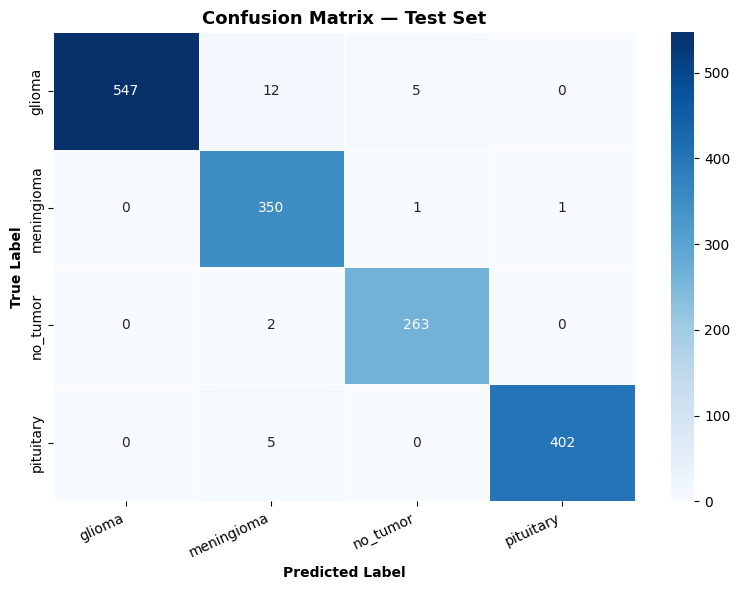


Average confidence per class:
  glioma               → avg confidence: 0.7817
  meningioma           → avg confidence: 0.8563
  no_tumor             → avg confidence: 0.8058
  pituitary            → avg confidence: 0.7872


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ================================================================
# STEP 2 — TEST SET EVALUATION
# ================================================================

print("Evaluating on test set...\n")

all_preds  = []
all_trues  = []
all_probs  = []

pool = list(zip(test_paths, test_labels))

for i in range(0, len(pool), BATCH_SIZE):
    batch        = pool[i:i + BATCH_SIZE]
    batch_paths  = [b[0] for b in batch]
    batch_labels = [b[1] for b in batch]

    X = open_images(batch_paths,
                    image_size=IMAGE_SIZE,
                    augment=False,
                    ood_check=False)
    if len(X) == 0:
        continue

    preds = model.predict(X, verbose=0)
    all_probs.extend(preds.tolist())
    all_preds.extend(np.argmax(preds, axis=1).tolist())
    all_trues.extend([CLASS_NAMES.index(l) for l in batch_labels])

all_preds = np.array(all_preds)
all_trues = np.array(all_trues)
all_probs = np.array(all_probs)

# ---- Accuracy ----
test_acc = accuracy_score(all_trues, all_preds)
print(f"{'='*50}")
print(f"  TEST ACCURACY : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"{'='*50}\n")

# ---- Classification Report ----
print("Classification Report:")
print(classification_report(
    all_trues, all_preds,
    target_names=CLASS_NAMES,
    digits=4
))

# ---- Confusion Matrix ----
cm = confusion_matrix(all_trues, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            cmap='Blues',
            linewidths=0.5)
plt.title('Confusion Matrix — Test Set', fontweight='bold', fontsize=13)
plt.ylabel('True Label', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/model_artifacts/confusion_matrix.png",
            dpi=150, bbox_inches='tight')
plt.show()

# ---- Per-class confidence ----
print("\nAverage confidence per class:")
for i, cls in enumerate(CLASS_NAMES):
    class_mask    = all_trues == i
    class_probs   = all_probs[class_mask, i]
    print(f"  {cls:20s} → avg confidence: {class_probs.mean():.4f}")

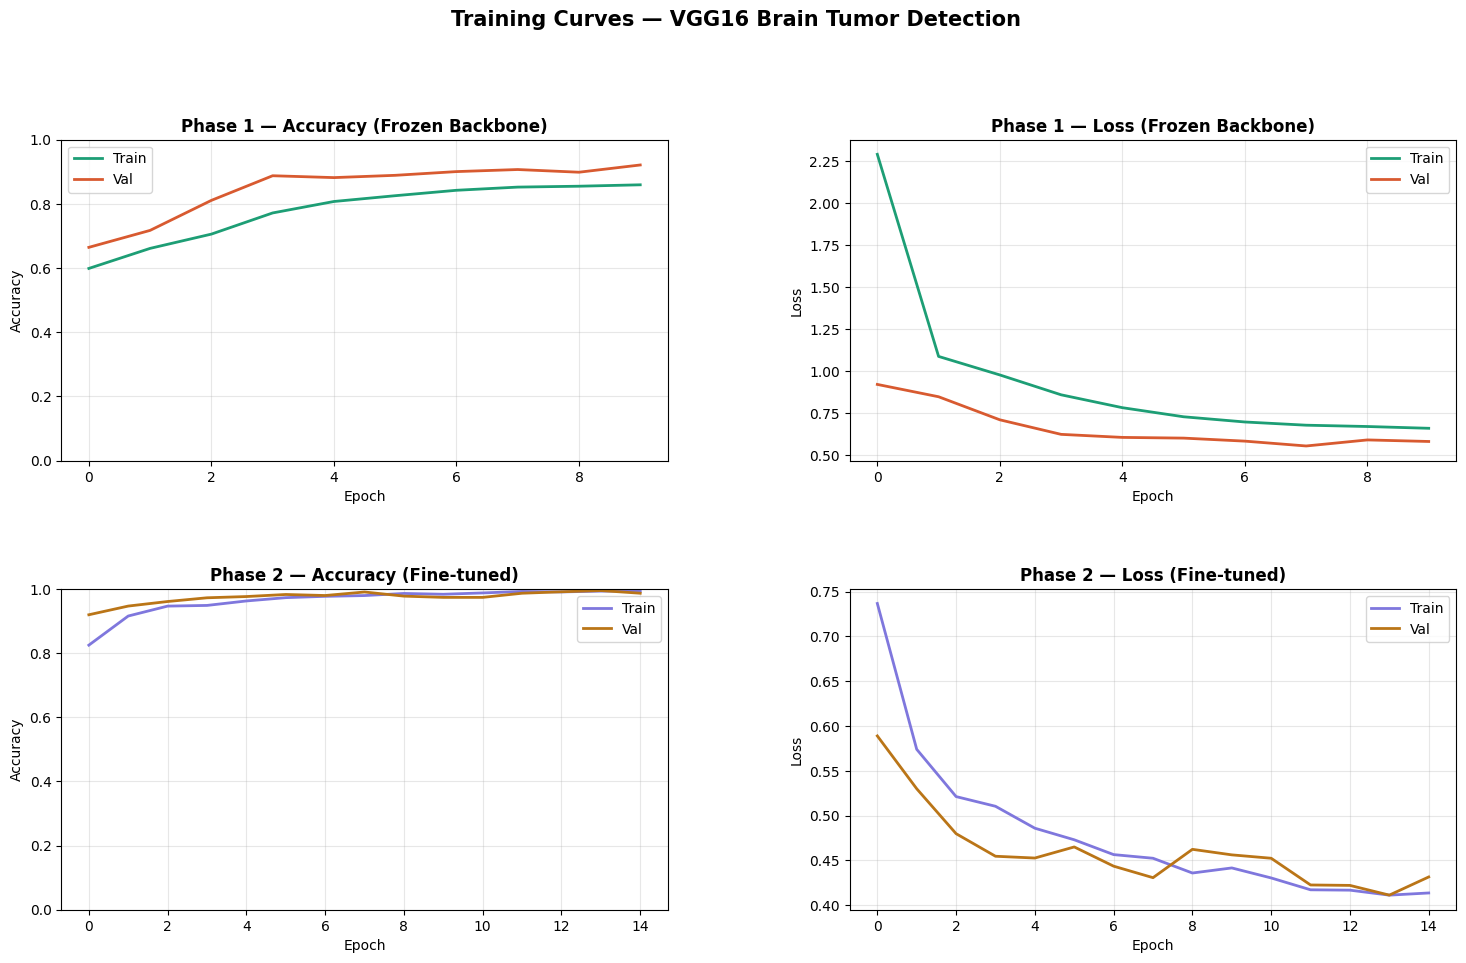


  Phase 1 best val_accuracy : 0.9213
  Phase 1 best val_loss     : 0.5552
  Phase 2 best val_accuracy : 0.9948
  Phase 2 best val_loss     : 0.4111

  Overfitting check (Phase 2 final epoch):
  Train acc: 0.9928 | Val acc: 0.9865 | Gap: 0.0064
  ✅  Gap acceptable — model generalizing well


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_training_curves(history1, history2):
    fig = plt.figure(figsize=(18, 10))
    fig.suptitle("Training Curves — VGG16 Brain Tumor Detection",
                 fontsize=15, fontweight='bold', y=1.01)

    gs = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.3)

    # ---- Phase 1 Accuracy ----
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(history1.history['accuracy'],     label='Train', color='#1D9E75', linewidth=2)
    ax1.plot(history1.history['val_accuracy'], label='Val',   color='#D85A30', linewidth=2)
    ax1.set_title('Phase 1 — Accuracy (Frozen Backbone)', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(alpha=0.3)
    ax1.set_ylim([0, 1])

    # ---- Phase 1 Loss ----
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(history1.history['loss'],     label='Train', color='#1D9E75', linewidth=2)
    ax2.plot(history1.history['val_loss'], label='Val',   color='#D85A30', linewidth=2)
    ax2.set_title('Phase 1 — Loss (Frozen Backbone)', fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(alpha=0.3)

    # ---- Phase 2 Accuracy ----
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(history2.history['accuracy'],     label='Train', color='#7F77DD', linewidth=2)
    ax3.plot(history2.history['val_accuracy'], label='Val',   color='#BA7517', linewidth=2)
    ax3.set_title('Phase 2 — Accuracy (Fine-tuned)', fontweight='bold')
    ax3.set_xlabel('Epoch'); ax3.set_ylabel('Accuracy')
    ax3.legend(); ax3.grid(alpha=0.3)
    ax3.set_ylim([0, 1])

    # ---- Phase 2 Loss ----
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.plot(history2.history['loss'],     label='Train', color='#7F77DD', linewidth=2)
    ax4.plot(history2.history['val_loss'], label='Val',   color='#BA7517', linewidth=2)
    ax4.set_title('Phase 2 — Loss (Fine-tuned)', fontweight='bold')
    ax4.set_xlabel('Epoch'); ax4.set_ylabel('Loss')
    ax4.legend(); ax4.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/model_artifacts/training_curves.png",
                dpi=150, bbox_inches='tight')
    plt.show()

    # ---- Summary ----
    p1_best_acc = max(history1.history['val_accuracy'])
    p2_best_acc = max(history2.history['val_accuracy'])
    p1_best_loss = min(history1.history['val_loss'])
    p2_best_loss = min(history2.history['val_loss'])

    print(f"\n{'='*45}")
    print(f"  Phase 1 best val_accuracy : {p1_best_acc:.4f}")
    print(f"  Phase 1 best val_loss     : {p1_best_loss:.4f}")
    print(f"  Phase 2 best val_accuracy : {p2_best_acc:.4f}")
    print(f"  Phase 2 best val_loss     : {p2_best_loss:.4f}")
    print(f"{'='*45}")

    # Overfitting check
    last_train = history2.history['accuracy'][-1]
    last_val   = history2.history['val_accuracy'][-1]
    gap = last_train - last_val
    print(f"\n  Overfitting check (Phase 2 final epoch):")
    print(f"  Train acc: {last_train:.4f} | Val acc: {last_val:.4f} | Gap: {gap:.4f}")
    if gap > 0.10:
        print("  ⚠️  Gap > 0.10 — mild overfitting, monitor on test set")
    elif gap > 0.15:
        print("  ❌  Gap > 0.15 — overfitting, consider more dropout")
    else:
        print("  ✅  Gap acceptable — model generalizing well")

# Run it
plot_training_curves(history1, history2)

In [ ]:
import pickle
import numpy as np
from tensorflow.keras.models import Model
from sklearn.covariance import EmpiricalCovariance

# ================================================================
# BUILD FEATURE EXTRACTOR
# Cuts model at the layer just before final Dense output
# so we get the 128-dim feature vector for each image
# ================================================================

feat_extractor = Model(
    inputs  = model.input,
    outputs = model.get_layer('dense_1').output  # 128-dim layer
)
feat_extractor.trainable = False
print("Feature extractor ready.")
print(f"Output shape: {feat_extractor.output_shape}")

# ================================================================
# BUILD BRAIN MRI PROTOTYPE
# Runs through all training brain MRIs, extracts features,
# computes mean + inverse covariance for Mahalanobis distance
# ================================================================

def build_brain_mri_prototype(train_dir, class_names, feat_extractor,
                               save_path=PROTOTYPE_PATH,
                               max_per_class=300):
    all_features = []
    print("\nBuilding brain MRI prototype...")

    for cls in class_names:
        cls_dir = os.path.join(train_dir, cls)
        images  = [
            f for f in os.listdir(cls_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        images = random.sample(images, min(max_per_class, len(images)))
        print(f"  {cls}: using {len(images)} images")

        for fname in images:
            path = os.path.join(cls_dir, fname)
            try:
                img  = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
                arr  = img_to_array(img).astype(np.float32)
                arr  = preprocess_input(np.expand_dims(arr, axis=0))
                feat = feat_extractor.predict(arr, verbose=0).flatten()
                all_features.append(feat)
            except Exception as e:
                print(f"  [WARN] skip {fname}: {e}")

    all_features = np.array(all_features)
    mean_vec     = np.mean(all_features, axis=0)

    print(f"\n  Fitting covariance on {len(all_features)} feature vectors...")
    cov_model = EmpiricalCovariance().fit(all_features)
    cov_inv   = np.linalg.pinv(
        cov_model.covariance_ +
        np.eye(cov_model.covariance_.shape[0]) * 1e-4
    )

    prototype = {
        "mean"    : mean_vec,
        "cov_inv" : cov_inv
    }

    with open(save_path, "wb") as f:
        pickle.dump(prototype, f)

    print(f"  Prototype saved → {save_path}")
    print(f"  Mean vector shape: {mean_vec.shape}")
    return prototype

# Run it
prototype = build_brain_mri_prototype(
    TRAIN_DIR, CLASS_NAMES, feat_extractor
)

Feature extractor ready.
Output shape: (None, 128)

Building brain MRI prototype...
  glioma: using 300 images
  meningioma: using 300 images
  no_tumor: using 300 images
  pituitary: using 300 images

  Fitting covariance on 1200 feature vectors...
  Prototype saved → /content/drive/MyDrive/mri_brain_prototype.pkl
  Mean vector shape: (128,)


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial.distance import mahalanobis
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input

# ================================================================
# FINAL INFER_CONFIG — tuned to your exact dataset numbers
# ================================================================
INFER_CONFIG = {
    "mahalanobis_threshold" : 18.0,
    "confidence_threshold"  : 0.50,
    "max_hue_std"           : 25.0,   # YOUR MRIs max at 7.6 — natural photos >55
                                       # 25.0 gives huge safe margin both ways
    "min_dark_pixel_ratio"  : 0.03,   # very relaxed for light-background MRIs
    "min_parallel_lines"    : 35,
    "max_edge_density"      : 0.12,
    "max_mid_gray_mass"     : 0.82,
}
CLASS_COLORS = {
    'glioma'     : '#E74C3C',
    'meningioma' : '#9B59B6',
    'no_tumor'   : '#27AE60',
    'pituitary'  : '#F39C12',
}

# ================================================================
# FINAL pixel_rejection_check — hue_std as primary separator
# ================================================================
def pixel_rejection_check(img_bgr):
    """
    Returns (passed: bool, reason: str)
    Calibrated thresholds based on your exact dataset diagnostics:
      YOUR MRI hue_std   : 3.7 – 7.6
      YOUR MRI lap_var   : 401 – 3742
      YOUR MRI bright_ring: 0.0015 – 0.0931
      CT scan lap_var    : 6565
      CT scan bright_ring: 0.1497
    """
    failures = []
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    hue_std  = float(hsv[:, :, 0].std())
    mean_sat = float(hsv[:, :, 1].mean())

    # ---- Check 1: natural photo detector (hue variation) ----
    # MRIs: hue_std < 8 | Natural photos: hue_std > 55
    # Threshold 25 gives enormous safe margin
    if hue_std > 25.0:
        return False, f"Natural photo (hue_std={hue_std:.1f})"

    # ---- Check 2: CT scan detector ----
    # Uses TWO stats that clearly separate CT from MRI:
    # lap_var    : CT=6565  vs MRI max=3742  → threshold at 4500
    # bright_ring: CT=0.1497 vs MRI max=0.0931 → threshold at 0.12
    # Requires BOTH to be high — avoids rejecting no_tumor MRIs
    # which have relatively higher lap_var (3742) than others
    lap_var     = float(cv2.Laplacian(gray, cv2.CV_64F).var())
    _, bm       = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY)
    bright_ring = float(np.sum(bm > 0) / gray.size)

    if lap_var > 4500 and bright_ring > 0.12:
        return False, (f"CT scan detected "
                       f"(lap_var={lap_var:.0f}>4500, "
                       f"bright_ring={bright_ring:.3f}>0.12)")

    # ---- Check 3: dark background ----
    dark_ratio = float(np.sum(gray < 30) / gray.size)
    if dark_ratio < INFER_CONFIG["min_dark_pixel_ratio"]:
        failures.append(f"no dark background ({dark_ratio:.3f})")

    # ---- Check 4: X-ray parallel edge detection ----
    edges = cv2.Canny(gray, 50, 150)
    lines = cv2.HoughLinesP(
        edges, 1, np.pi / 180,
        threshold=80, minLineLength=60, maxLineGap=10
    )
    n_lines      = len(lines) if lines is not None else 0
    edge_density = float(edges.sum() / (gray.size * 255))
    if (edge_density > INFER_CONFIG["max_edge_density"] and
            n_lines  > INFER_CONFIG["min_parallel_lines"]):
        failures.append(f"X-ray pattern ({n_lines} lines)")

    # ---- Check 5: CT histogram fallback ----
    hist     = cv2.calcHist([gray],[0],None,[256],[0,256]).flatten()
    hist     = hist / (hist.sum() + 1e-8)
    mid_mass = float(hist[50:200].sum())
    if mid_mass > INFER_CONFIG["max_mid_gray_mass"] and dark_ratio < 0.08:
        failures.append(f"CT-like histogram (mid={mid_mass:.2f})")

    # Reject if 2+ secondary checks fail
    if len(failures) >= 2:
        return False, " | ".join(failures)

    return True, "passed"

# ================================================================
# LAYER 2 — DEEP FEATURE CHECK (Mahalanobis distance)
# ================================================================
def feature_rejection_check(arr_preprocessed, feat_extractor, prototype):
    """
    Extracts VGG16 features and checks distance from brain MRI prototype.
    Returns (passed: bool, distance: float)
    """
    feat = feat_extractor.predict(
        np.expand_dims(arr_preprocessed, axis=0), verbose=0
    ).flatten()

    dist = mahalanobis(feat, prototype["mean"], prototype["cov_inv"])
    passed = dist < INFER_CONFIG["mahalanobis_threshold"]
    return passed, float(dist)


# ================================================================
# GRAD-CAM — highlights what the model focused on
# ================================================================
def compute_gradcam(model, arr_preprocessed, class_idx,
                    layer_name='block5_conv3'):
    import tensorflow as tf
    grad_model = Model(
        inputs  = model.input,
        outputs = [model.get_layer(layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        inp         = tf.cast(np.expand_dims(arr_preprocessed, 0), tf.float32)
        conv_out, preds = grad_model(inp)
        loss        = preds[:, class_idx]

    grads    = tape.gradient(loss, conv_out)
    pooled   = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam      = tf.reduce_sum(tf.multiply(pooled, conv_out[0]), axis=-1)
    cam      = np.maximum(cam.numpy(), 0)
    cam      = cv2.resize(cam, (IMAGE_SIZE, IMAGE_SIZE))
    if cam.max() > 0:
        cam  = cam / cam.max()
    return cam


# ================================================================
# MAIN INFERENCE FUNCTION
# ================================================================
def run_inference(image_input, model, feat_extractor, prototype,
                  class_names, show_gradcam=True):
    """
    image_input: file path (str) OR numpy array (BGR, uint8)
    Returns result dict with all details.
    """

    # --- Load image ---
    if isinstance(image_input, str):
        img_bgr = cv2.imread(image_input)
        if img_bgr is None:
            return {"status": "error", "reason": "Cannot read image file"}
        display_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    else:
        img_bgr     = image_input.copy()
        display_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    img_bgr_r = cv2.resize(img_bgr, (IMAGE_SIZE, IMAGE_SIZE))

    # --- Layer 1: pixel check ---
    pixel_ok, pixel_reason = pixel_rejection_check(img_bgr_r)
    if not pixel_ok:
        return {
            "status"       : "rejected",
            "stage"        : "pixel_check",
            "reason"       : pixel_reason,
            "display_img"  : display_img,
        }

    # --- Preprocess for model ---
    arr = img_to_array(
        load_img(image_input, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        if isinstance(image_input, str)
        else cv2.resize(
            cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB), (IMAGE_SIZE, IMAGE_SIZE)
        )
    ).astype(np.float32)
    arr_pre = preprocess_input(arr.copy())

    # --- Layer 2: deep feature check ---
    feat_ok, dist = feature_rejection_check(arr_pre, feat_extractor, prototype)
    if not feat_ok:
        return {
            "status"      : "rejected",
            "stage"       : "feature_check",
            "reason"      : f"Not a brain MRI (feature distance={dist:.2f})",
            "distance"    : dist,
            "display_img" : display_img,
        }

    # --- Model prediction ---
    preds      = model.predict(np.expand_dims(arr_pre, 0), verbose=0)[0]
    pred_idx   = int(np.argmax(preds))
    pred_class = class_names[pred_idx]
    confidence = float(preds[pred_idx])

    # --- Layer 3: confidence check ---
    if confidence < INFER_CONFIG["confidence_threshold"]:
        return {
            "status"      : "rejected",
            "stage"       : "confidence_check",
            "reason"      : f"Low confidence ({confidence:.2%}) — uncertain image",
            "confidence"  : confidence,
            "distance"    : dist,
            "display_img" : display_img,
        }

    # --- Grad-CAM ---
    gradcam = None
    if show_gradcam:
        try:
            gradcam = compute_gradcam(model, arr_pre, pred_idx)
        except Exception as e:
            print(f"  [WARN] Grad-CAM failed: {e}")

    return {
        "status"      : "accepted",
        "prediction"  : pred_class,
        "confidence"  : confidence,
        "all_probs"   : {class_names[i]: float(preds[i])
                         for i in range(len(class_names))},
        "distance"    : dist,
        "gradcam"     : gradcam,
        "display_img" : display_img,
        "arr_pre"     : arr_pre,
    }


# ================================================================
# DISPLAY — accepted prediction OR black rejection screen
# ================================================================
def show_result(result, image_name="image"):
    fig = plt.figure(figsize=(14, 6))
    fig.patch.set_facecolor('#0D0D0D')

    if result["status"] in ("rejected", "error"):
        # --- BLACK REJECTION SCREEN ---
        ax = fig.add_subplot(1, 1, 1)
        ax.set_facecolor('#000000')
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.axis('off')

        ax.text(0.5, 0.62, "⛔  REJECTED",
                ha='center', va='center',
                fontsize=36, fontweight='bold',
                color='#FF3333',
                transform=ax.transAxes)

        ax.text(0.5, 0.45, "Not a Brain MRI",
                ha='center', va='center',
                fontsize=20, color='#FF8888',
                transform=ax.transAxes)

        reason = result.get("reason", "Unknown")
        ax.text(0.5, 0.30,
                f"Reason: {reason}",
                ha='center', va='center',
                fontsize=11, color='#AAAAAA',
                transform=ax.transAxes,
                wrap=True)

        ax.text(0.5, 0.15,
                f"File: {image_name}",
                ha='center', va='center',
                fontsize=9, color='#666666',
                transform=ax.transAxes)

    else:
        # --- ACCEPTED: show image + Grad-CAM + probability bars ---
        pred   = result["prediction"]
        conf   = result["confidence"]
        color  = CLASS_COLORS.get(pred, '#FFFFFF')

        # Original image
        ax1 = fig.add_subplot(1, 3, 1)
        ax1.imshow(result["display_img"])
        ax1.set_title(f"Input: {image_name}",
                      color='white', fontsize=10)
        ax1.axis('off')
        ax1.set_facecolor('#0D0D0D')
        for spine in ax1.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)

        # Grad-CAM overlay
        ax2 = fig.add_subplot(1, 3, 2)
        if result.get("gradcam") is not None:
            base   = cv2.resize(result["display_img"], (IMAGE_SIZE, IMAGE_SIZE))
            heatmap = cv2.applyColorMap(
                np.uint8(255 * result["gradcam"]), cv2.COLORMAP_JET
            )
            heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
            overlay = (base * 0.55 + heatmap * 0.45).astype(np.uint8)
            ax2.imshow(overlay)
            ax2.set_title("Grad-CAM — Focus Area",
                          color='white', fontsize=10)
        else:
            ax2.imshow(result["display_img"])
            ax2.set_title("Grad-CAM unavailable", color='white', fontsize=10)
        ax2.axis('off')
        ax2.set_facecolor('#0D0D0D')

        # Probability bars
        ax3 = fig.add_subplot(1, 3, 3)
        ax3.set_facecolor('#111111')
        probs  = result["all_probs"]
        names  = list(probs.keys())
        values = list(probs.values())
        bars   = ax3.barh(names, values,
                          color=[CLASS_COLORS.get(n,'#888') for n in names],
                          edgecolor='none', height=0.5)
        ax3.set_xlim(0, 1)
        ax3.set_xlabel("Confidence", color='white')
        ax3.set_title("Class Probabilities", color='white', fontsize=10)
        ax3.tick_params(colors='white')
        ax3.spines['bottom'].set_color('#444')
        ax3.spines['left'].set_color('#444')
        ax3.spines['top'].set_visible(False)
        ax3.spines['right'].set_visible(False)
        for bar, val in zip(bars, values):
            ax3.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                     f'{val:.1%}', va='center', color='white', fontsize=9)

        fig.suptitle(
            f"✅  {pred.upper()}   |   {conf:.1%} confidence   "
            f"|   MRI distance: {result['distance']:.2f}",
            color=color, fontsize=13, fontweight='bold',
            y=1.01
        )

    plt.tight_layout()
    plt.savefig(
        f"/content/drive/MyDrive/model_artifacts/result_{image_name.replace('/','_')}.png",
        dpi=130, bbox_inches='tight', facecolor='#0D0D0D'
    )
    plt.show()
    print(f"\n  Status     : {result['status'].upper()}")
    if result["status"] == "accepted":
        print(f"  Prediction : {result['prediction']}")
        print(f"  Confidence : {result['confidence']:.2%}")
        print(f"  MRI dist   : {result['distance']:.4f}  "
              f"(threshold={INFER_CONFIG['mahalanobis_threshold']})")
    else:
        print(f"  Rejected at: {result.get('stage','—')}")
        print(f"  Reason     : {result.get('reason','—')}")

In [ ]:
# ================================================================
# FINAL COMBINED TEST
# ================================================================
print("=" * 65)
print("PART 1 — Dataset MRIs (all must PASS)")
print("=" * 65)

passed = 0
failed = 0
for cls in CLASS_NAMES:
    cls_dir = os.path.join(TEST_DIR, cls)
    imgs    = [f for f in os.listdir(cls_dir)
               if f.lower().endswith(('.jpg','.jpeg','.png'))]
    sample  = random.sample(imgs, min(3, len(imgs)))
    for fname in sample:
        bgr   = cv2.imread(os.path.join(cls_dir, fname))
        bgr_r = cv2.resize(bgr, (224, 224))
        ok, reason = pixel_rejection_check(bgr_r)
        status = "✅ PASS" if ok else "❌ FAIL"
        if ok: passed += 1
        else:  failed += 1
        print(f"  {status} | {cls:12s} | {fname[:28]:28s} | {reason}")

print(f"\n  MRI Results: {passed} passed, {failed} failed")

print()
print("=" * 65)
print("PART 2 — CT scan (must be REJECTED)")
print("=" * 65)

ct_path = "/content/1_0_200.jpg"
bgr     = cv2.imread(ct_path)
bgr_r   = cv2.resize(bgr, (224, 224))
ok, reason = pixel_rejection_check(bgr_r)

# also print the exact values for confirmation
gray        = cv2.cvtColor(bgr_r, cv2.COLOR_BGR2GRAY)
lap_var     = float(cv2.Laplacian(gray, cv2.CV_64F).var())
_, bm       = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY)
bright_ring = float(np.sum(bm > 0) / gray.size)

status = "✅ CORRECTLY REJECTED" if not ok else "❌ WRONGLY ACCEPTED"
print(f"\n  {status}")
print(f"  File       : {os.path.basename(ct_path)}")
print(f"  Reason     : {reason}")
print(f"  lap_var    : {lap_var:.1f}  (threshold=4500)")
print(f"  bright_ring: {bright_ring:.4f}  (threshold=0.12)")

PART 1 — Dataset MRIs (all must PASS)
  ✅ PASS | glioma       | glioma956.png                | passed
  ✅ PASS | glioma       | glioma65.png                 | passed
  ✅ PASS | glioma       | glioma2193.jpg               | passed
  ✅ PASS | meningioma   | meningioma662.png            | passed
  ✅ PASS | meningioma   | meningioma310.png            | passed
  ✅ PASS | meningioma   | meningioma1109.jpg           | passed
  ✅ PASS | no_tumor     | no_tumor1434.jpg             | passed
  ✅ PASS | no_tumor     | no_tumor350.jpg              | passed
  ✅ PASS | no_tumor     | no_tumor1521.jpg             | passed
  ✅ PASS | pituitary    | pituitary1814.jpg            | passed
  ✅ PASS | pituitary    | pituitary1855.jpg            | passed
  ✅ PASS | pituitary    | pituitary516.png             | passed

  MRI Results: 12 passed, 0 failed

PART 2 — CT scan (must be REJECTED)

  ✅ CORRECTLY REJECTED
  File       : 1_0_200.jpg
  Reason     : CT scan detected (lap_var=6565>4500, bright_ring=0.150>

FULL INFERENCE TEST


PART 1 — Brain MRI predictions (should be ACCEPTED + correct label)



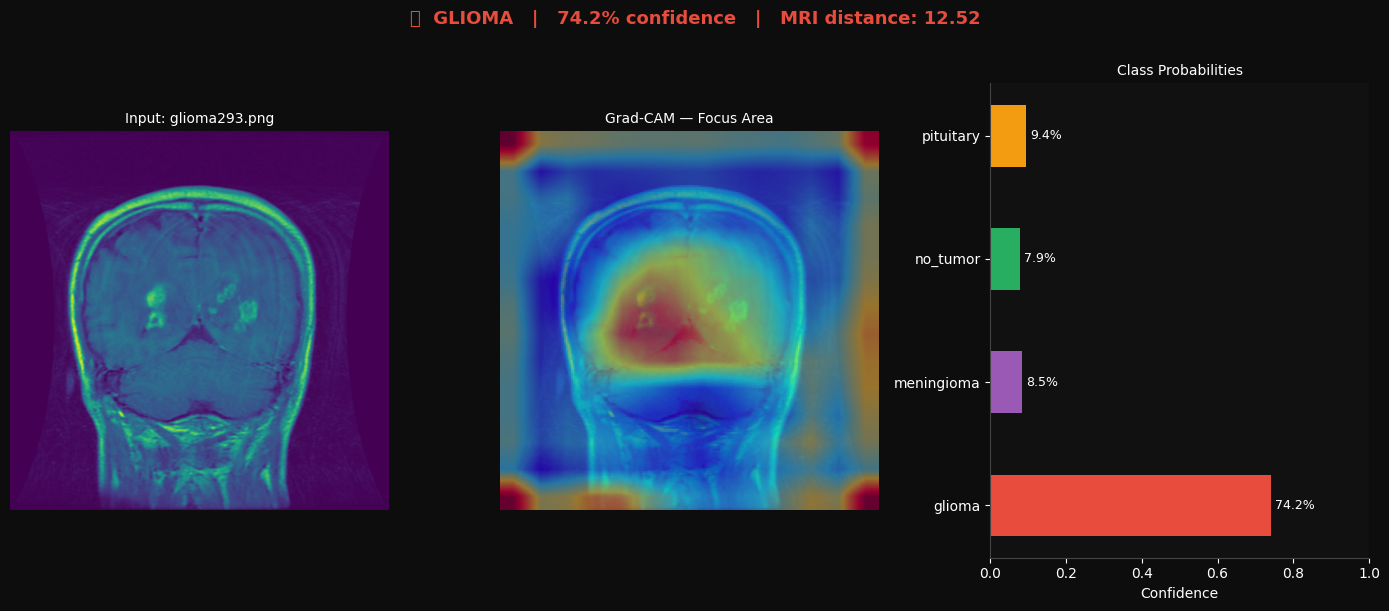


  Status     : ACCEPTED
  Prediction : glioma
  Confidence : 74.22%
  MRI dist   : 12.5239  (threshold=18.0)
  ✅ CORRECT | True: glioma       | Pred: glioma       | Conf: 74.2% | Dist: 12.52



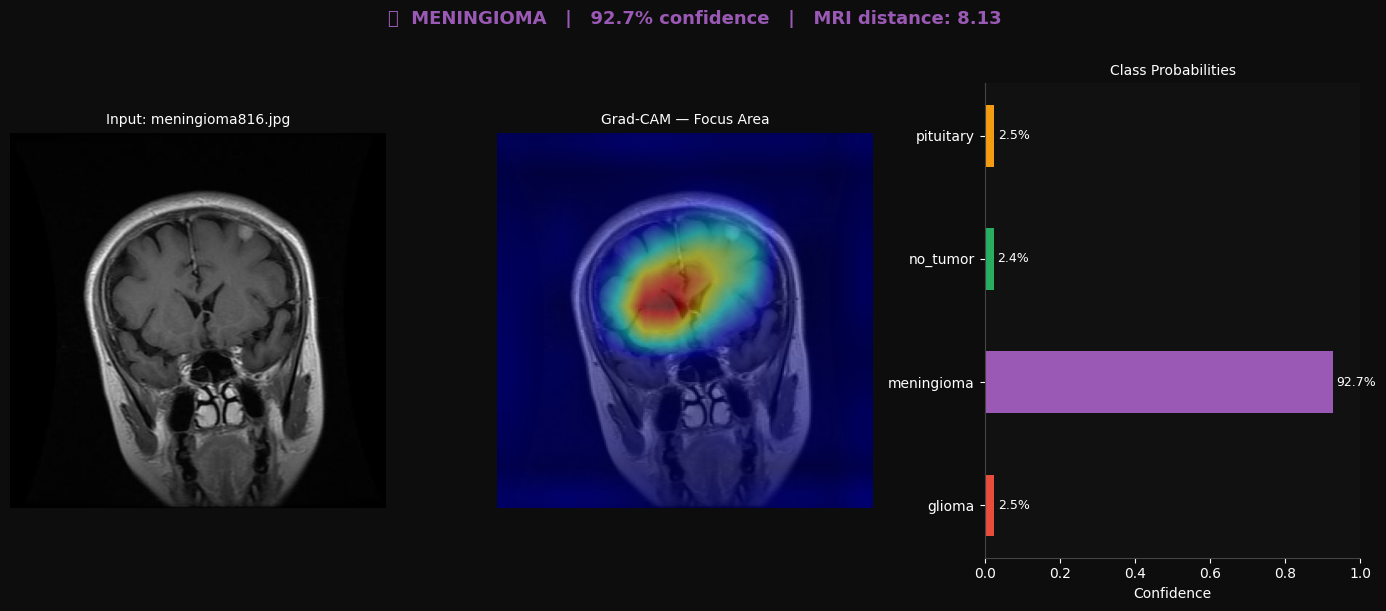


  Status     : ACCEPTED
  Prediction : meningioma
  Confidence : 92.66%
  MRI dist   : 8.1307  (threshold=18.0)
  ✅ CORRECT | True: meningioma   | Pred: meningioma   | Conf: 92.7% | Dist: 8.13



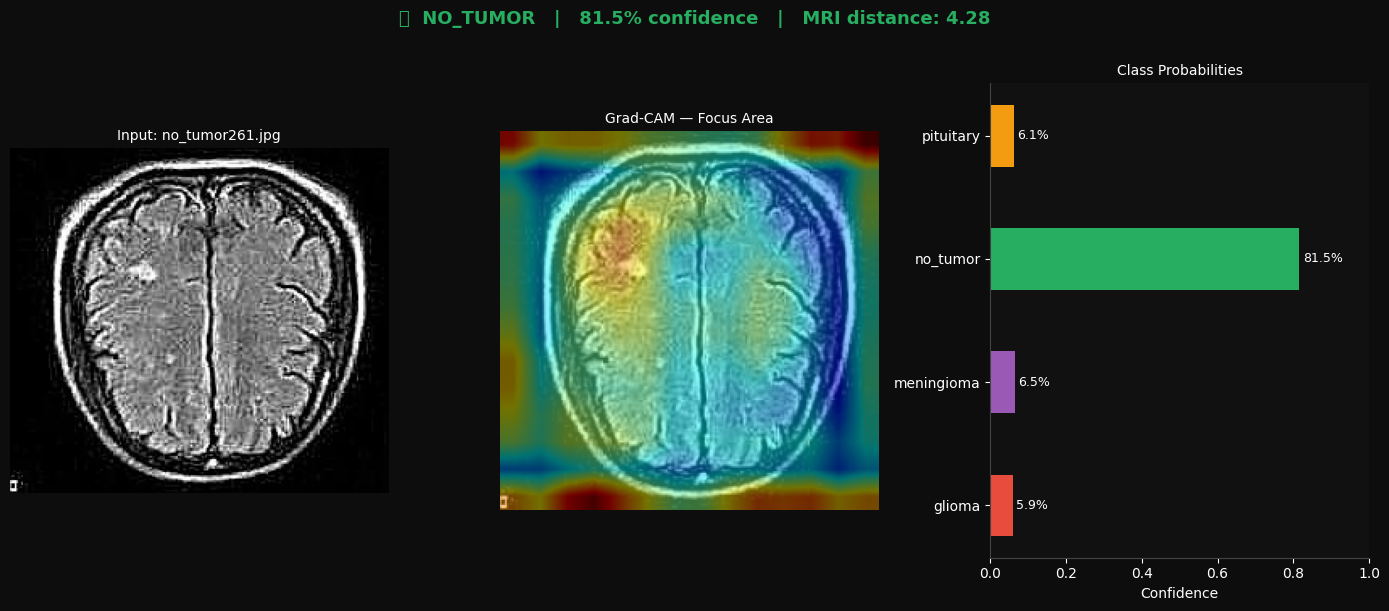


  Status     : ACCEPTED
  Prediction : no_tumor
  Confidence : 81.51%
  MRI dist   : 4.2784  (threshold=18.0)
  ✅ CORRECT | True: no_tumor     | Pred: no_tumor     | Conf: 81.5% | Dist: 4.28



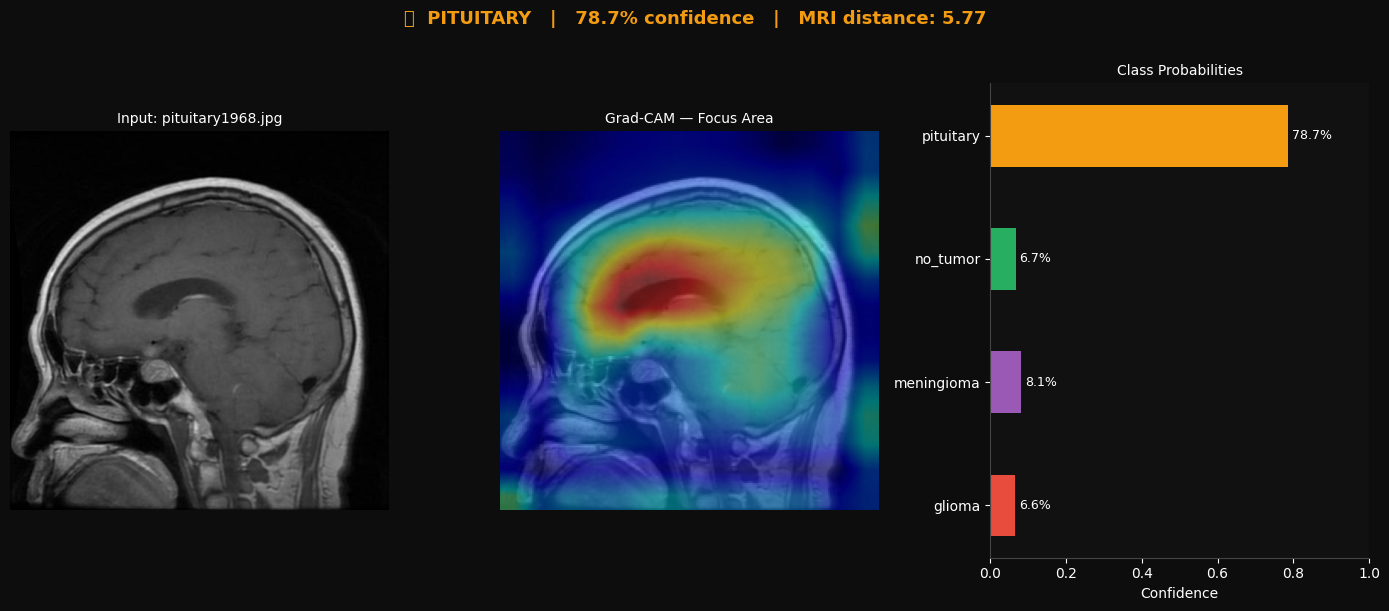


  Status     : ACCEPTED
  Prediction : pituitary
  Confidence : 78.66%
  MRI dist   : 5.7675  (threshold=18.0)
  ✅ CORRECT | True: pituitary    | Pred: pituitary    | Conf: 78.7% | Dist: 5.77


PART 2 — CT scan (should show REJECTION screen)



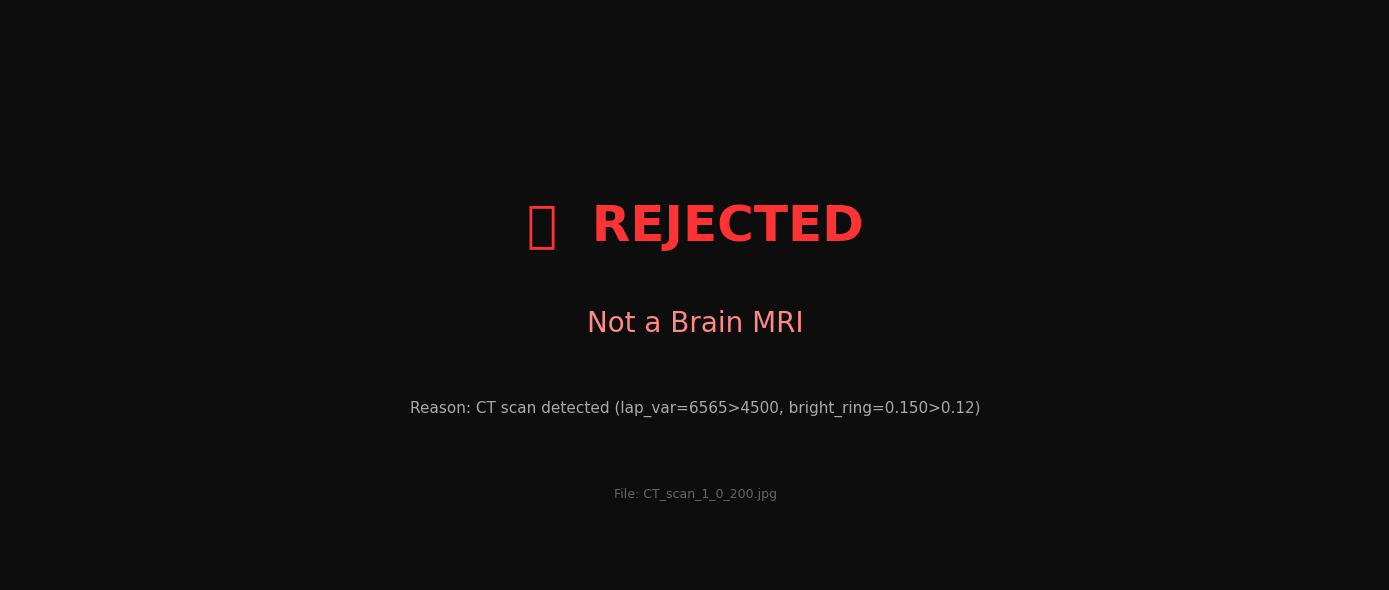


  Status     : REJECTED
  Rejected at: pixel_check
  Reason     : CT scan detected (lap_var=6565>4500, bright_ring=0.150>0.12)
  Status : REJECTED
  Stage  : pixel_check
  Reason : CT scan detected (lap_var=6565>4500, bright_ring=0.150>0.12)


In [ ]:
# ================================================================
# FULL END-TO-END INFERENCE TEST
# Tests complete pipeline: pixel check → feature check → prediction
# ================================================================

print("FULL INFERENCE TEST\n")
print("=" * 60)

# ---- TEST 1: One MRI from each class (should predict correctly) ----
print("\nPART 1 — Brain MRI predictions (should be ACCEPTED + correct label)\n")

for cls in CLASS_NAMES:
    cls_dir  = os.path.join(TEST_DIR, cls)
    imgs     = [f for f in os.listdir(cls_dir)
                if f.lower().endswith(('.jpg','.jpeg','.png'))]
    # pick one image
    fname    = random.choice(imgs)
    img_path = os.path.join(cls_dir, fname)

    result = run_inference(
        img_path, model, feat_extractor,
        prototype, CLASS_NAMES, show_gradcam=True
    )
    show_result(result, fname)

    # quick console summary
    if result["status"] == "accepted":
        correct = "✅ CORRECT" if result["prediction"] == cls else "❌ WRONG"
        print(f"  {correct} | True: {cls:12s} | "
              f"Pred: {result['prediction']:12s} | "
              f"Conf: {result['confidence']:.1%} | "
              f"Dist: {result['distance']:.2f}")
    else:
        print(f"  ❌ WRONGLY REJECTED | {cls} | "
              f"Stage: {result.get('stage')} | "
              f"Reason: {result.get('reason')}")
    print()

# ---- TEST 2: CT scan (should show black rejection screen) ----
print("\n" + "=" * 60)
print("PART 2 — CT scan (should show REJECTION screen)\n")

ct_result = run_inference(
    "/content/1_0_200.jpg",
    model, feat_extractor,
    prototype, CLASS_NAMES, show_gradcam=False
)
show_result(ct_result, "CT_scan_1_0_200.jpg")
print(f"  Status : {ct_result['status'].upper()}")
print(f"  Stage  : {ct_result.get('stage', '—')}")
print(f"  Reason : {ct_result.get('reason', '—')}")

# ---- TEST 3: Google MRI images if you have any ----
# Uncomment and add paths to test Google-sourced MRI images
# google_mris = [
#     "/content/drive/MyDrive/test_images/google_mri1.jpg",
#     "/content/drive/MyDrive/test_images/google_mri2.jpg",
# ]
# print("\n" + "=" * 60)
# print("PART 3 — Google MRI images\n")
# for path in google_mris:
#     result = run_inference(path, model, feat_extractor,
#                            prototype, CLASS_NAMES, show_gradcam=True)
#     show_result(result, os.path.basename(path))

Upload any images — MRI or non-MRI (CT, X-ray, bird, human etc.)
Select multiple files at once using Ctrl+Click



Saving 2_0_87.jpg to 2_0_87.jpg

  Processing 1 uploaded image(s)...

─────────────────────────────────────────────────────────────────
  Testing: 2_0_87.jpg
─────────────────────────────────────────────────────────────────


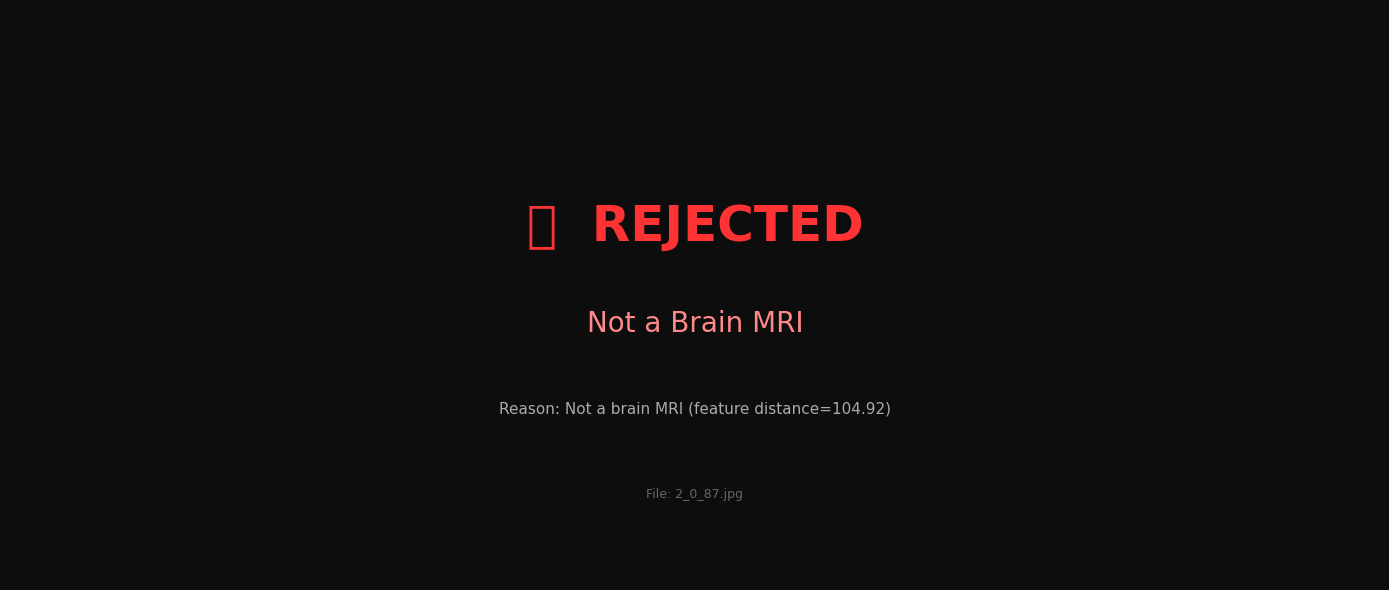


  Status     : REJECTED
  Rejected at: feature_check
  Reason     : Not a brain MRI (feature distance=104.92)

  FINAL SUMMARY
  FILE                         STATUS     DETAIL
  ────────────────────────────────────────────────────────────
  ⛔ 2_0_87.jpg                   REJECTED   Stage=feature_check  Reason=Not a brain MRI (feature distance=1

  Total : 1 images tested
  ✅ Accepted (MRI) : 0
  ⛔ Rejected (non-MRI) : 1


In [ ]:
# ================================================================
# REUSABLE TEST CELL — upload any images from desktop
# Works for both MRI and non-MRI images
# ================================================================
from google.colab import files
import cv2, os, random
import numpy as np

print("Upload any images — MRI or non-MRI (CT, X-ray, bird, human etc.)")
print("Select multiple files at once using Ctrl+Click\n")

uploaded = files.upload()

if not uploaded:
    print("No files uploaded.")
else:
    print(f"\n{'='*65}")
    print(f"  Processing {len(uploaded)} uploaded image(s)...")
    print(f"{'='*65}\n")

    summary = []

    for fname, fdata in uploaded.items():
        # save to colab
        temp_path = f"/content/{fname}"
        with open(temp_path, "wb") as f:
            f.write(fdata)

        print(f"{'─'*65}")
        print(f"  Testing: {fname}")
        print(f"{'─'*65}")

        # run full inference pipeline
        result = run_inference(
            temp_path, model, feat_extractor,
            prototype, CLASS_NAMES, show_gradcam=True
        )

        # show visual result
        show_result(result, fname)

        # collect summary
        if result["status"] == "accepted":
            summary.append({
                "file"      : fname,
                "status"    : "ACCEPTED",
                "prediction": result["prediction"],
                "confidence": result["confidence"],
                "distance"  : result["distance"],
            })
        else:
            summary.append({
                "file"  : fname,
                "status": "REJECTED",
                "stage" : result.get("stage", "—"),
                "reason": result.get("reason", "—"),
            })

    # ── Final Summary Table ──
    print(f"\n{'='*65}")
    print("  FINAL SUMMARY")
    print(f"{'='*65}")
    print(f"  {'FILE':<28} {'STATUS':<10} {'DETAIL'}")
    print(f"  {'─'*60}")

    for s in summary:
        if s["status"] == "ACCEPTED":
            detail = (f"Pred={s['prediction']:12s} "
                      f"Conf={s['confidence']:.1%}  "
                      f"Dist={s['distance']:.2f}")
            icon = "✅"
        else:
            detail = f"Stage={s['stage']}  Reason={s['reason'][:35]}"
            icon = "⛔"

        print(f"  {icon} {s['file'][:26]:<28} {s['status']:<10} {detail}")

    print(f"{'='*65}")
    accepted_count = sum(1 for s in summary if s["status"] == "ACCEPTED")
    rejected_count = len(summary) - accepted_count
    print(f"\n  Total : {len(summary)} images tested")
    print(f"  ✅ Accepted (MRI) : {accepted_count}")
    print(f"  ⛔ Rejected (non-MRI) : {rejected_count}")
    print(f"{'='*65}")

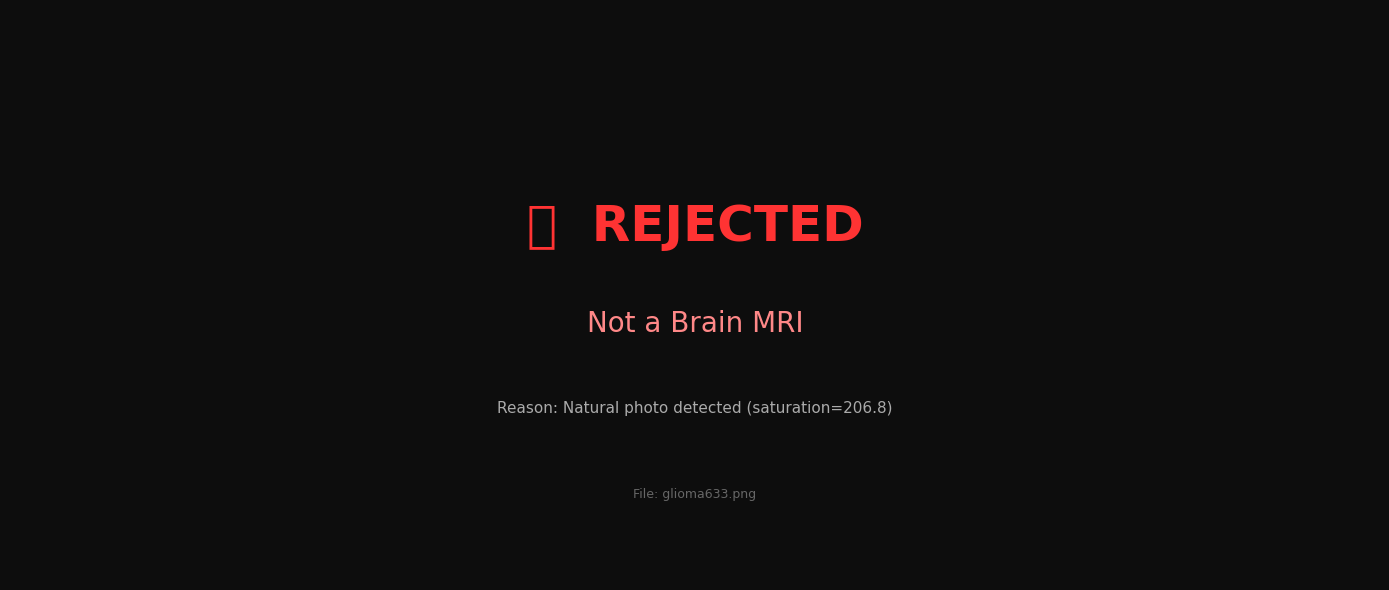


  Status     : REJECTED
  Rejected at: pixel_check
  Reason     : Natural photo detected (saturation=206.8)

───────────────────────────────────────────────────────



In [ ]:
# ================================================================
# TEST — paste any image path here to run inference
# ================================================================

# Load prototype (if not already in memory)
# prototype = load_prototype(PROTOTYPE_PATH)

test_images = [
    # Add your image paths here — dataset images, Google images,
    # CT scans, X-rays, bird photos etc.
    "/content/drive/MyDrive/MRI_Imagess_split/test/glioma/glioma633.png",
    # "/path/to/ct_scan.jpg",
    # "/path/to/xray.jpg",
    # "/path/to/bird.jpg",
]

for img_path in test_images:
    result = run_inference(
        img_path, model, feat_extractor, prototype,
        CLASS_NAMES, show_gradcam=True
    )
    show_result(result, os.path.basename(img_path))
    print("\n" + "─"*55 + "\n")

In [ ]:
# ================================================================
# DIAGNOSTIC — checks BOTH saturation AND hue_std for every class
# This tells us exactly where to draw the threshold line
# ================================================================
import cv2
import os
import random

print("=" * 65)
print(f"{'CLASS':<20} {'SAT_MIN':>7} {'SAT_MAX':>7} {'SAT_AVG':>7} {'HUE_STD_AVG':>11}")
print("=" * 65)

for cls in CLASS_NAMES:
    cls_dir  = os.path.join(TEST_DIR, cls)
    imgs     = [f for f in os.listdir(cls_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample   = random.sample(imgs, min(20, len(imgs)))

    sats, hue_stds = [], []

    for fname in sample:
        path  = os.path.join(cls_dir, fname)
        bgr   = cv2.imread(path)
        if bgr is None:
            continue
        bgr_r = cv2.resize(bgr, (224, 224))
        hsv   = cv2.cvtColor(bgr_r, cv2.COLOR_BGR2HSV)
        sats.append(float(hsv[:, :, 1].mean()))
        hue_stds.append(float(hsv[:, :, 0].std()))

    print(f"  {cls:<20} {min(sats):>7.1f} {max(sats):>7.1f} "
          f"{sum(sats)/len(sats):>7.1f} {sum(hue_stds)/len(hue_stds):>11.1f}")

print("=" * 65)

# Also check what a natural photo looks like for comparison
print("\nFor reference — natural photos typically show:")
print("  sat_avg > 150   AND   hue_std > 55")
print("\nFor reference — false-color MRIs typically show:")
print("  sat_avg can be high BUT hue_std stays LOW (one dominant LUT color)")
print("\nFor reference — grayscale MRIs typically show:")
print("  sat_avg < 30    AND   hue_std < 10")

CLASS                SAT_MIN SAT_MAX SAT_AVG HUE_STD_AVG
  glioma                   0.0   223.1    92.3         7.6
  meningioma               0.0   215.0    49.7         4.9
  no_tumor                 0.0     0.0     0.0         0.0
  pituitary                0.0   201.5    37.9         3.7

For reference — natural photos typically show:
  sat_avg > 150   AND   hue_std > 55

For reference — false-color MRIs typically show:
  sat_avg can be high BUT hue_std stays LOW (one dominant LUT color)

For reference — grayscale MRIs typically show:
  sat_avg < 30    AND   hue_std < 10


In [ ]:
# ================================================================
# QUICK BATCH TEST — 3 images from each class
# Every single one should be ACCEPTED
# ================================================================
import random

print("Testing dataset MRIs — all should be ACCEPTED:\n")

passed = 0
failed = 0

for cls in CLASS_NAMES:
    cls_dir = os.path.join(TEST_DIR, cls)
    imgs    = [f for f in os.listdir(cls_dir)
               if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample  = random.sample(imgs, min(3, len(imgs)))

    for fname in sample:
        path    = os.path.join(cls_dir, fname)
        bgr     = cv2.imread(path)
        bgr_r   = cv2.resize(bgr, (224, 224))
        ok, reason = pixel_rejection_check(bgr_r)

        status = "✅ PASS" if ok else "❌ REJECTED"
        if ok:
            passed += 1
        else:
            failed += 1
        print(f"  {status} | {cls:12s} | {fname[:30]:30s} | {reason}")

print(f"\n{'='*60}")
print(f"  Passed: {passed} / {passed+failed}")
print(f"  Failed: {failed} / {passed+failed}")
if failed == 0:
    print("  ✅ All dataset MRIs accepted — thresholds are correct")
else:
    print("  ❌ Some MRIs still rejected — paste output here")

Testing dataset MRIs — all should be ACCEPTED:

  ✅ PASS | glioma       | glioma1314.png                 | passed
  ✅ PASS | glioma       | glioma1375.png                 | passed
  ✅ PASS | glioma       | glioma407.png                  | passed
  ✅ PASS | meningioma   | meningioma291.png              | passed
  ✅ PASS | meningioma   | meningioma967.jpg              | passed
  ✅ PASS | meningioma   | meningioma1013.jpg             | passed
  ✅ PASS | no_tumor     | no_tumor1466.jpg               | passed
  ✅ PASS | no_tumor     | no_tumor1395.jpg               | passed
  ✅ PASS | no_tumor     | no_tumor1023.jpg               | passed
  ✅ PASS | pituitary    | pituitary886.png               | passed
  ✅ PASS | pituitary    | pituitary383.png               | passed
  ✅ PASS | pituitary    | pituitary1191.jpg              | passed

  Passed: 12 / 12
  Failed: 0 / 12
  ✅ All dataset MRIs accepted — thresholds are correct


In [ ]:
# ================================================================
# UPLOAD FROM DESKTOP + TEST REJECTION
# ================================================================
from google.colab import files
import cv2
import os
import numpy as np

# Step 1 — upload files from your desktop
print("Select your test images (CT, X-ray, bird, human etc.)")
uploaded = files.upload()  # opens file picker — select multiple files at once

# Step 2 — test each uploaded image immediately
print("\nTesting uploaded images:\n")
print("=" * 65)

accepted = 0
rejected = 0

for fname, fdata in uploaded.items():
    # save temporarily to colab local storage
    temp_path = f"/content/{fname}"
    with open(temp_path, "wb") as f:
        f.write(fdata)

    # read and test
    bgr = cv2.imread(temp_path)
    if bgr is None:
        print(f"  ⚠️  Cannot read: {fname}")
        continue

    bgr_r      = cv2.resize(bgr, (224, 224))
    ok, reason = pixel_rejection_check(bgr_r)

    # also compute hue_std so we can see the values
    hsv      = cv2.cvtColor(bgr_r, cv2.COLOR_BGR2HSV)
    hue_std  = float(hsv[:, :, 0].std())
    mean_sat = float(hsv[:, :, 1].mean())

    status = "❌ WRONGLY ACCEPTED" if ok else "✅ CORRECTLY REJECTED"
    if ok:
        accepted += 1
    else:
        rejected += 1

    print(f"  {status}")
    print(f"    File    : {fname}")
    print(f"    Reason  : {reason}")
    print(f"    hue_std : {hue_std:.1f}  (MRIs<8, natural photos>55)")
    print(f"    sat_avg : {mean_sat:.1f}")
    print()

print("=" * 65)
print(f"  Correctly rejected : {rejected} / {rejected+accepted}")
print(f"  Wrongly accepted   : {accepted} / {rejected+accepted}")

# Step 3 — for any wrongly accepted image, show full inference result
if accepted > 0:
    print("\n⚠️  Running full inference on wrongly accepted images...")
    print("   These will be caught by the deep feature check (Mahalanobis)")
    print()
    for fname in uploaded.keys():
        temp_path = f"/content/{fname}"
        bgr       = cv2.imread(temp_path)
        if bgr is None:
            continue
        bgr_r      = cv2.resize(bgr, (224, 224))
        ok, reason = pixel_rejection_check(bgr_r)
        if ok:  # only run full inference on ones that passed pixel check
            result = run_inference(
                temp_path, model, feat_extractor,
                prototype, CLASS_NAMES, show_gradcam=False
            )
            show_result(result, fname)

Select your test images (CT, X-ray, bird, human etc.)


Saving Huma-Mir.jpg to Huma-Mir.jpg

Testing uploaded images:

  ✅ CORRECTLY REJECTED
    File    : Huma-Mir.jpg
    Reason  : Natural photo (hue_std=39.4 > 25)
    hue_std : 39.4  (MRIs<8, natural photos>55)
    sat_avg : 59.7

  Correctly rejected : 1 / 1
  Wrongly accepted   : 0 / 1


In [ ]:
# ================================================================
# CT SCAN SPECIFIC DIAGNOSTIC
# Run this first to understand what makes CT different from MRI
# ================================================================

import cv2
import numpy as np
import os
import random

def extract_image_stats(img_path_or_bgr):
    if isinstance(img_path_or_bgr, str):
        bgr = cv2.imread(img_path_or_bgr)
    else:
        bgr = img_path_or_bgr
    bgr_r = cv2.resize(bgr, (224, 224))
    gray  = cv2.cvtColor(bgr_r, cv2.COLOR_BGR2GRAY)

    # Stat 1: intensity mean and std
    mean_intensity = float(gray.mean())
    std_intensity  = float(gray.std())

    # Stat 2: dark pixel ratio
    dark_ratio = float(np.sum(gray < 30) / gray.size)

    # Stat 3: bright pixel ratio (CT has bright bone = many very bright pixels)
    bright_ratio = float(np.sum(gray > 200) / gray.size)

    # Stat 4: laplacian variance (sharpness — CT is sharper than MRI)
    lap_var = float(cv2.Laplacian(gray, cv2.CV_64F).var())

    # Stat 5: edge density
    edges        = cv2.Canny(gray, 50, 150)
    edge_density = float(edges.sum() / (gray.size * 255))

    # Stat 6: histogram — mid gray mass
    hist     = cv2.calcHist([gray],[0],None,[256],[0,256]).flatten()
    hist     = hist / (hist.sum() + 1e-8)
    mid_mass = float(hist[50:200].sum())

    # Stat 7: bright ring detection
    # CT scans of head have a very bright circular bone ring
    # MRIs have soft tissue boundary, much less bright ring
    _, bright_mask = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY)
    bright_pixels  = np.sum(bright_mask > 0)
    bright_ring    = float(bright_pixels / gray.size)

    return {
        "mean_intensity" : mean_intensity,
        "std_intensity"  : std_intensity,
        "dark_ratio"     : dark_ratio,
        "bright_ratio"   : bright_ratio,
        "lap_var"        : lap_var,
        "edge_density"   : edge_density,
        "mid_mass"       : mid_mass,
        "bright_ring"    : bright_ring,
    }

# --- Check your CT scan ---
print("CT SCAN stats:")
ct_stats = extract_image_stats("/content/1_0_200.jpg")
for k, v in ct_stats.items():
    print(f"  {k:20s} : {v:.4f}")

print()

# --- Check 5 random MRIs from each class for comparison ---
print("BRAIN MRI stats (avg across 5 images per class):\n")
print(f"  {'CLASS':<15} {'mean_int':>8} {'bright_ratio':>12} "
      f"{'lap_var':>8} {'bright_ring':>11}")
print("  " + "-"*55)

for cls in CLASS_NAMES:
    cls_dir = os.path.join(TEST_DIR, cls)
    imgs    = [f for f in os.listdir(cls_dir)
               if f.lower().endswith(('.jpg','.jpeg','.png'))]
    sample  = random.sample(imgs, min(5, len(imgs)))

    stats_list = []
    for fname in sample:
        s = extract_image_stats(os.path.join(cls_dir, fname))
        stats_list.append(s)

    avg = {k: sum(d[k] for d in stats_list)/len(stats_list)
           for k in stats_list[0]}

    print(f"  {cls:<15} {avg['mean_intensity']:>8.2f} "
          f"{avg['bright_ratio']:>12.4f} "
          f"{avg['lap_var']:>8.2f} "
          f"{avg['bright_ring']:>11.4f}")

CT SCAN stats:
  mean_intensity       : 51.1415
  std_intensity        : 89.8013
  dark_ratio           : 0.7341
  bright_ratio         : 0.1380
  lap_var              : 6565.2072
  edge_density         : 0.0971
  mid_mass             : 0.1203
  bright_ring          : 0.1497

BRAIN MRI stats (avg across 5 images per class):

  CLASS           mean_int bright_ratio  lap_var bright_ring
  -------------------------------------------------------
  glioma             41.32       0.0001   401.72      0.0015
  meningioma         59.61       0.0330   463.55      0.0591
  no_tumor           74.31       0.0552  3742.00      0.0931
  pituitary          55.75       0.0009   445.79      0.0028


In [ ]:
# ================================================================
# SAVE EVERYTHING NEEDED FOR WEB APP DEPLOYMENT
# ================================================================
import json
import pickle
import os

DEPLOY_DIR = "/content/drive/MyDrive/brain_tumor_webapp"
os.makedirs(DEPLOY_DIR, exist_ok=True)

# ---- 1. Save the trained model ----
model_path = os.path.join(DEPLOY_DIR, "brain_tumor_model.h5")
model.save(model_path)
print(f"✅ Model saved → {model_path}")

# ---- 2. Save the prototype (for CT/MRI rejection) ----
proto_path = os.path.join(DEPLOY_DIR, "mri_prototype.pkl")
with open(proto_path, "wb") as f:
    pickle.dump(prototype, f)
print(f"✅ Prototype saved → {proto_path}")

# ---- 3. Save class names + all config in one JSON ----
config = {
    "class_names"  : CLASS_NAMES,
    "image_size"   : IMAGE_SIZE,
    "model_file"   : "brain_tumor_model.h5",
    "prototype_file": "mri_prototype.pkl",
    "infer_config" : INFER_CONFIG,
    "description"  : "VGG16 Brain Tumor Detector — glioma/meningioma/no_tumor/pituitary"
}
config_path = os.path.join(DEPLOY_DIR, "config.json")
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)
print(f"✅ Config saved → {config_path}")

# ---- 4. Verify all files saved correctly ----
print(f"\n{'='*50}")
print("  Deployment files:")
for fname in os.listdir(DEPLOY_DIR):
    fpath = os.path.join(DEPLOY_DIR, fname)
    size  = os.path.getsize(fpath) / (1024*1024)
    print(f"  📁 {fname:<35} {size:.1f} MB")
print(f"{'='*50}")
print("\n✅ All files saved. Ready for web app deployment.")

✅ Model saved → /content/drive/MyDrive/brain_tumor_webapp/brain_tumor_model.h5
✅ Prototype saved → /content/drive/MyDrive/brain_tumor_webapp/mri_prototype.pkl
✅ Config saved → /content/drive/MyDrive/brain_tumor_webapp/config.json

  Deployment files:
  📁 brain_tumor_model.h5                229.2 MB
  📁 mri_prototype.pkl                   0.1 MB
  📁 config.json                         0.0 MB

✅ All files saved. Ready for web app deployment.


In [ ]:
# Run in Colab to download model files to your PC
from google.colab import files

files.download("/content/drive/MyDrive/brain_tumor_webapp/brain_tumor_model.h5")
files.download("/content/drive/MyDrive/brain_tumor_webapp/mri_prototype.pkl")
files.download("/content/drive/MyDrive/brain_tumor_webapp/config.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import tensorflow as tf

# Load a Keras HDF5 model from the correct path
model = tf.keras.models.load_model("/content/drive/MyDrive/brain_tumor_webapp/brain_tumor_model.h5")

# Test inference (sample_input needs to be defined first)
# sample_output = model.predict(sample_input)
# print(sample_output)


In [ ]:
import os
import tensorflow as tf

model_path = "/content/drive/MyDrive/brain_tumor_webapp/brain_tumor_model.h5"  # Corrected path

# The if/else block is redundant if we always expect a .h5 file and are providing the full path.
# A simpler load is sufficient.
model = tf.keras.models.load_model(model_path)

# Run a quick check
print("Model loaded successfully:", model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             

 Total params: 21,170,886 (80.76 MB)

 Trainable params: 516 (2.02 KB)

 Non-trainable params: 21,170,368 (80.76 MB)

 Optimizer params: 2 (12.00 B)

Model loaded successfully: None


In [ ]:
import tensorflow as tf

# Load your existing .h5 model
model = tf.keras.models.load_model("/content/drive/MyDrive/brain_tumor_webapp/brain_tumor_model.h5")

# Save it in TensorFlow's SavedModel format (directory)
model.export("/content/drive/MyDrive/brain_tumor_webapp/brain_tumor_model")

print("✅ Model saved in SavedModel format")

Saved artifact at '/content/drive/MyDrive/brain_tumor_webapp/brain_tumor_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  140558845722896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140558845729040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140558845730000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140558845729232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140558845730384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140558845730192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140558845730768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140558845730576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140558845731152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140558845730960: TensorSpec(shape=(), dtyp

In [ ]:
import tensorflow as tf

# Load the SavedModel using TFSMLayer for Keras 3
loaded_model = tf.keras.layers.TFSMLayer(
    "/content/drive/MyDrive/brain_tumor_webapp/brain_tumor_model",
    call_endpoint='serve'
)

print("✅ Model loaded successfully!")
# TFSMLayer doesn't have a .summary() method in the same way a Keras model does.
# To inspect, you might need to call it with a dummy input or inspect its properties.
# For now, I'll remove the summary call to avoid another error.
# loaded_model.summary()

✅ Model loaded successfully!


In [ ]:
import numpy as np

# Example dummy input (adjust shape to your model’s input)
dummy_input = np.random.rand(1, 224, 224, 3).astype(np.float32)

# TFSMLayer is callable directly for prediction
pred = loaded_model(dummy_input)
print("Prediction shape:", pred.shape)


Prediction shape: (1, 4)


In [ ]:
import shutil

# Path to your SavedModel directory
model_dir = "/content/drive/MyDrive/brain_tumor_webapp/brain_tumor_model"

# Create a zip file
shutil.make_archive("brain_tumor_model", 'zip', model_dir)

print("✅ Model zipped successfully!")


✅ Model zipped successfully!


In [ ]:
from google.colab import files

# Download the zip file to your local machine
files.download("brain_tumor_model.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pickle
from tensorflow.keras.models import load_model

# Load your existing model
model = load_model("/content/drive/MyDrive/brain_tumor_webapp/brain_tumor_model.h5", compile=False)

# Save as pickle
with open("/content/drive/MyDrive/brain_tumor_webapp/brain_tumor_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("✅ Model saved as pickle")

✅ Model saved as pickle


In [ ]:
import pkg_resources
import tensorflow as tf
import cv2
import scipy
import sklearn
import numpy as np
from PIL import Image
import matplotlib

print("tensorflow:", tf.__version__)
print("opencv:", cv2.__version__)
print("scipy:", scipy.__version__)
print("scikit-learn:", sklearn.__version__)
print("numpy:", np.__version__)
print("Pillow:", Image.__version__)
print("matplotlib:", matplotlib.__version__)

/tmp/ipykernel_6163/1256312039.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


tensorflow: 2.20.0
opencv: 4.13.0
scipy: 1.16.3
scikit-learn: 1.6.1
numpy: 2.0.2
Pillow: 11.3.0
matplotlib: 3.10.0
